<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Problema de Orszag-Tang
</h3>

<p>
Problema de Orszag--Tang mediante una implementación desarrollada en Python.
</p>

</div>

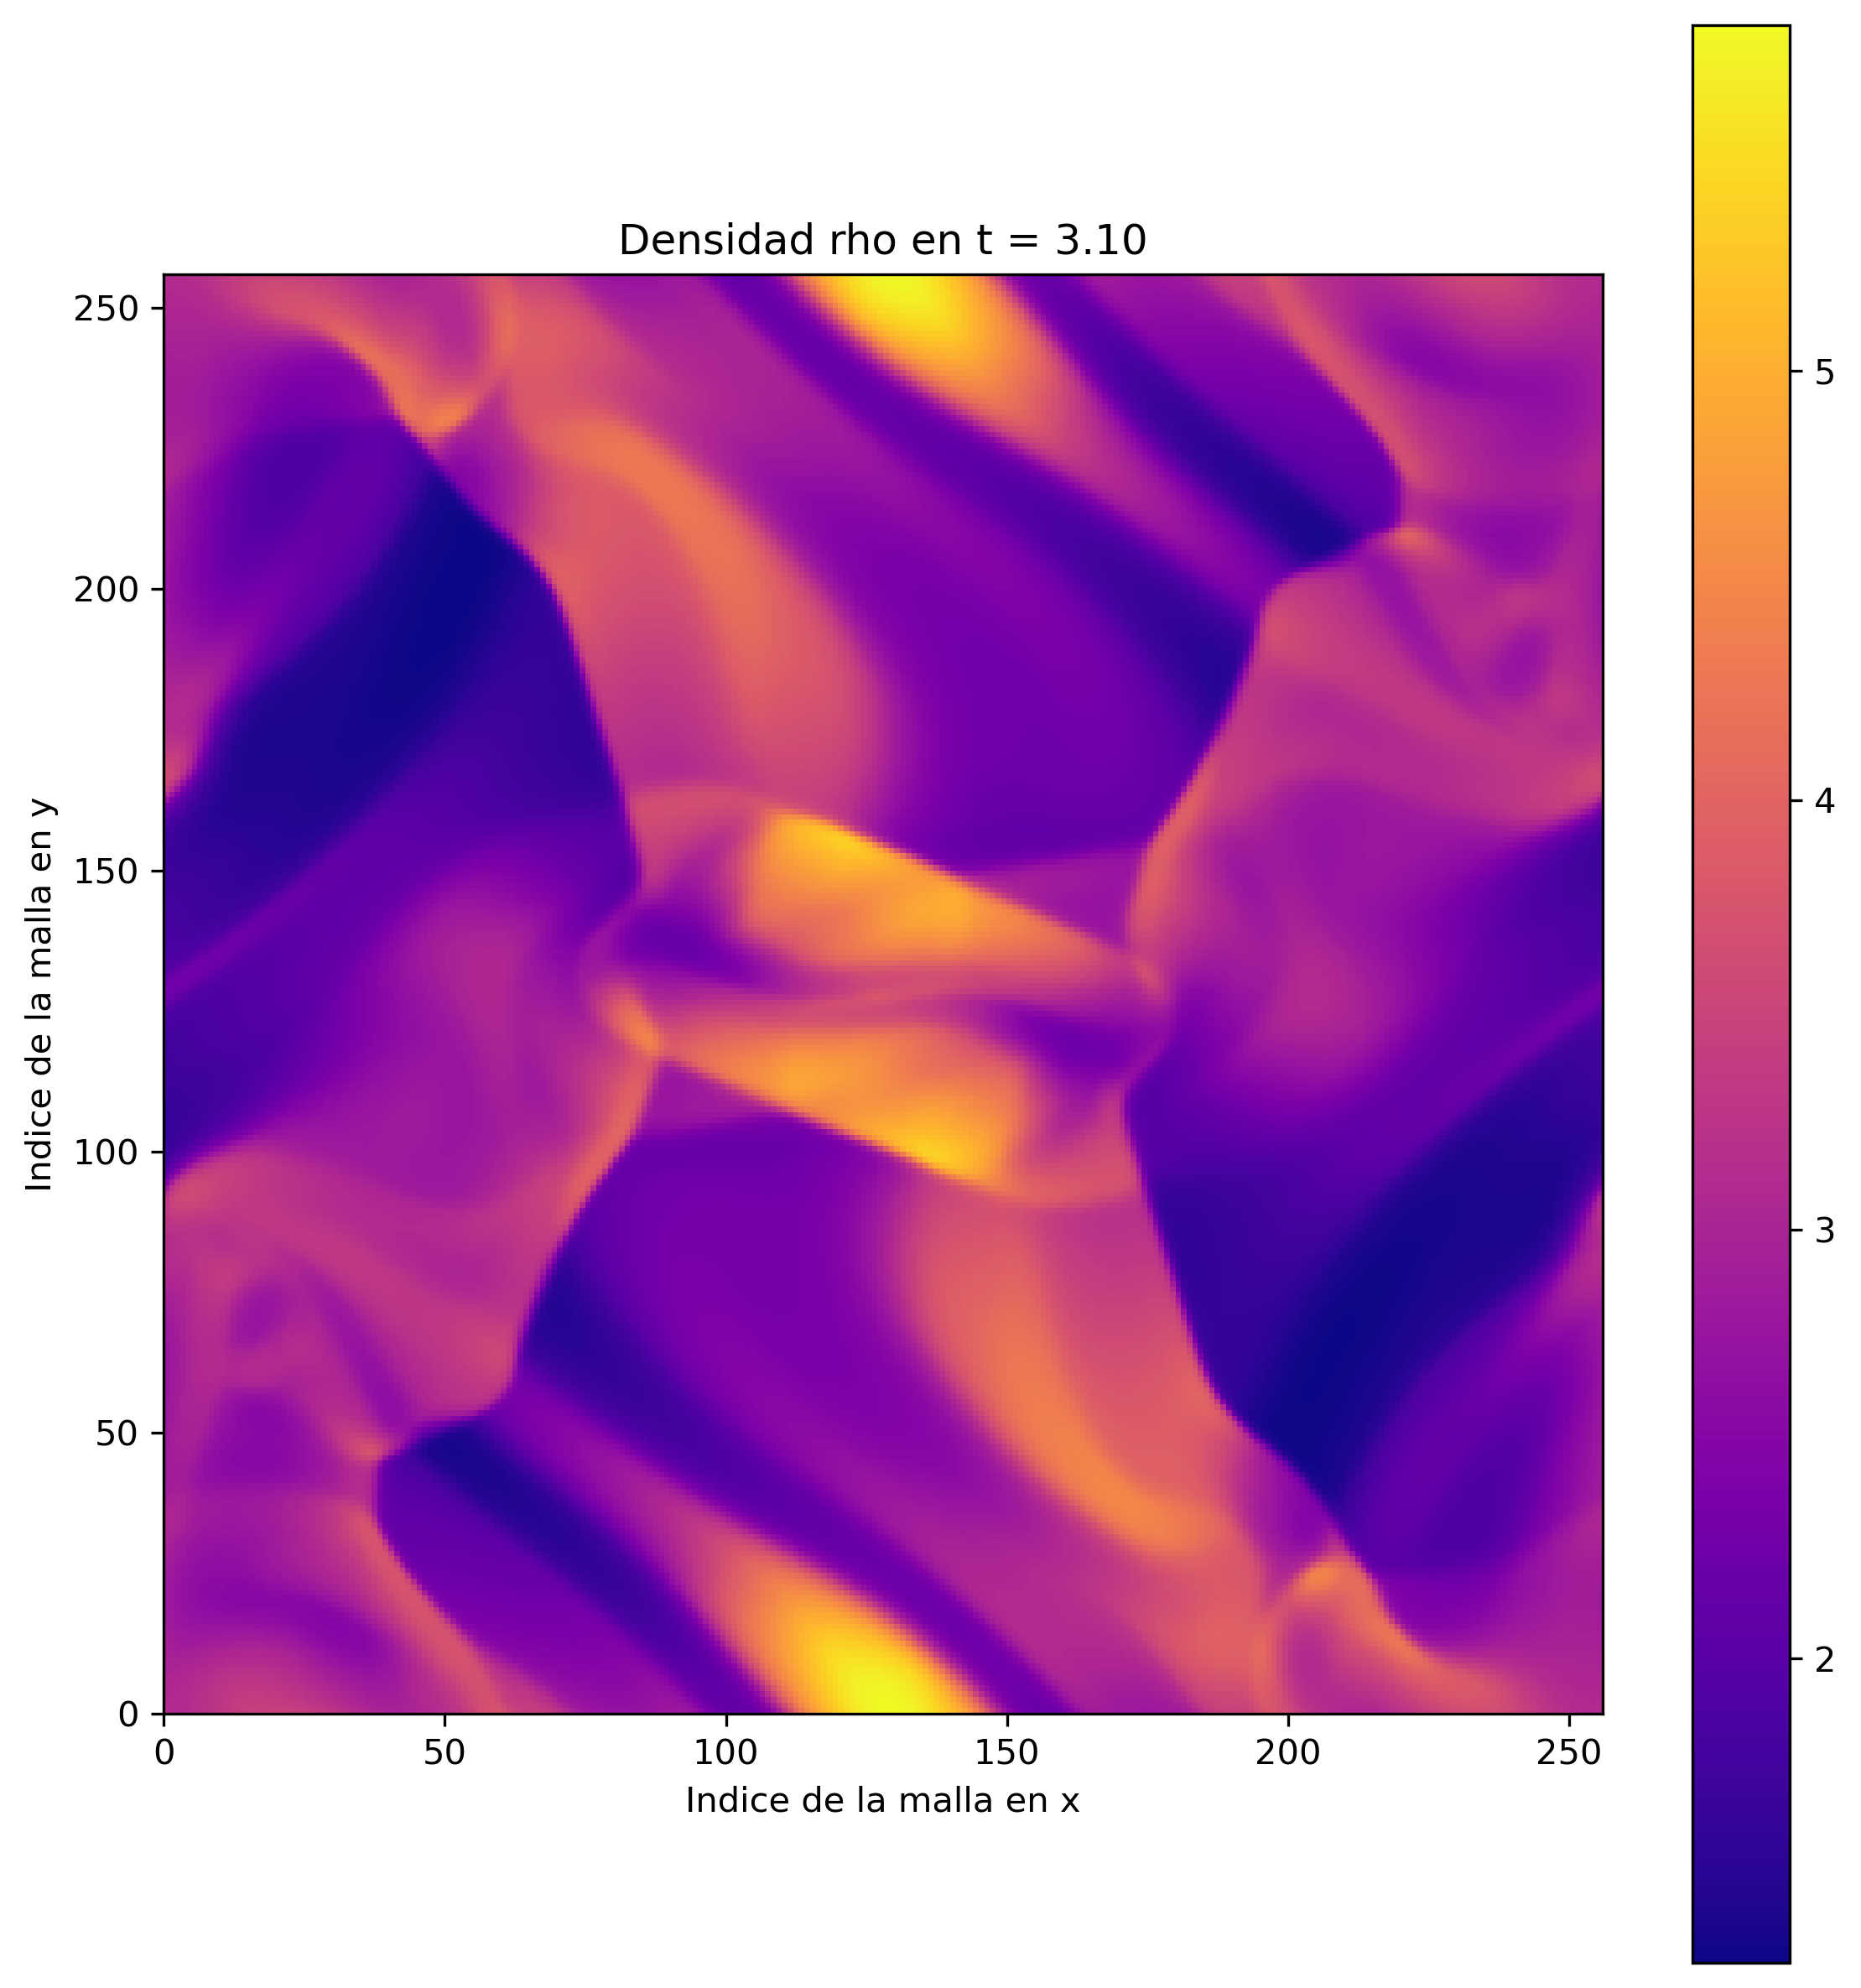

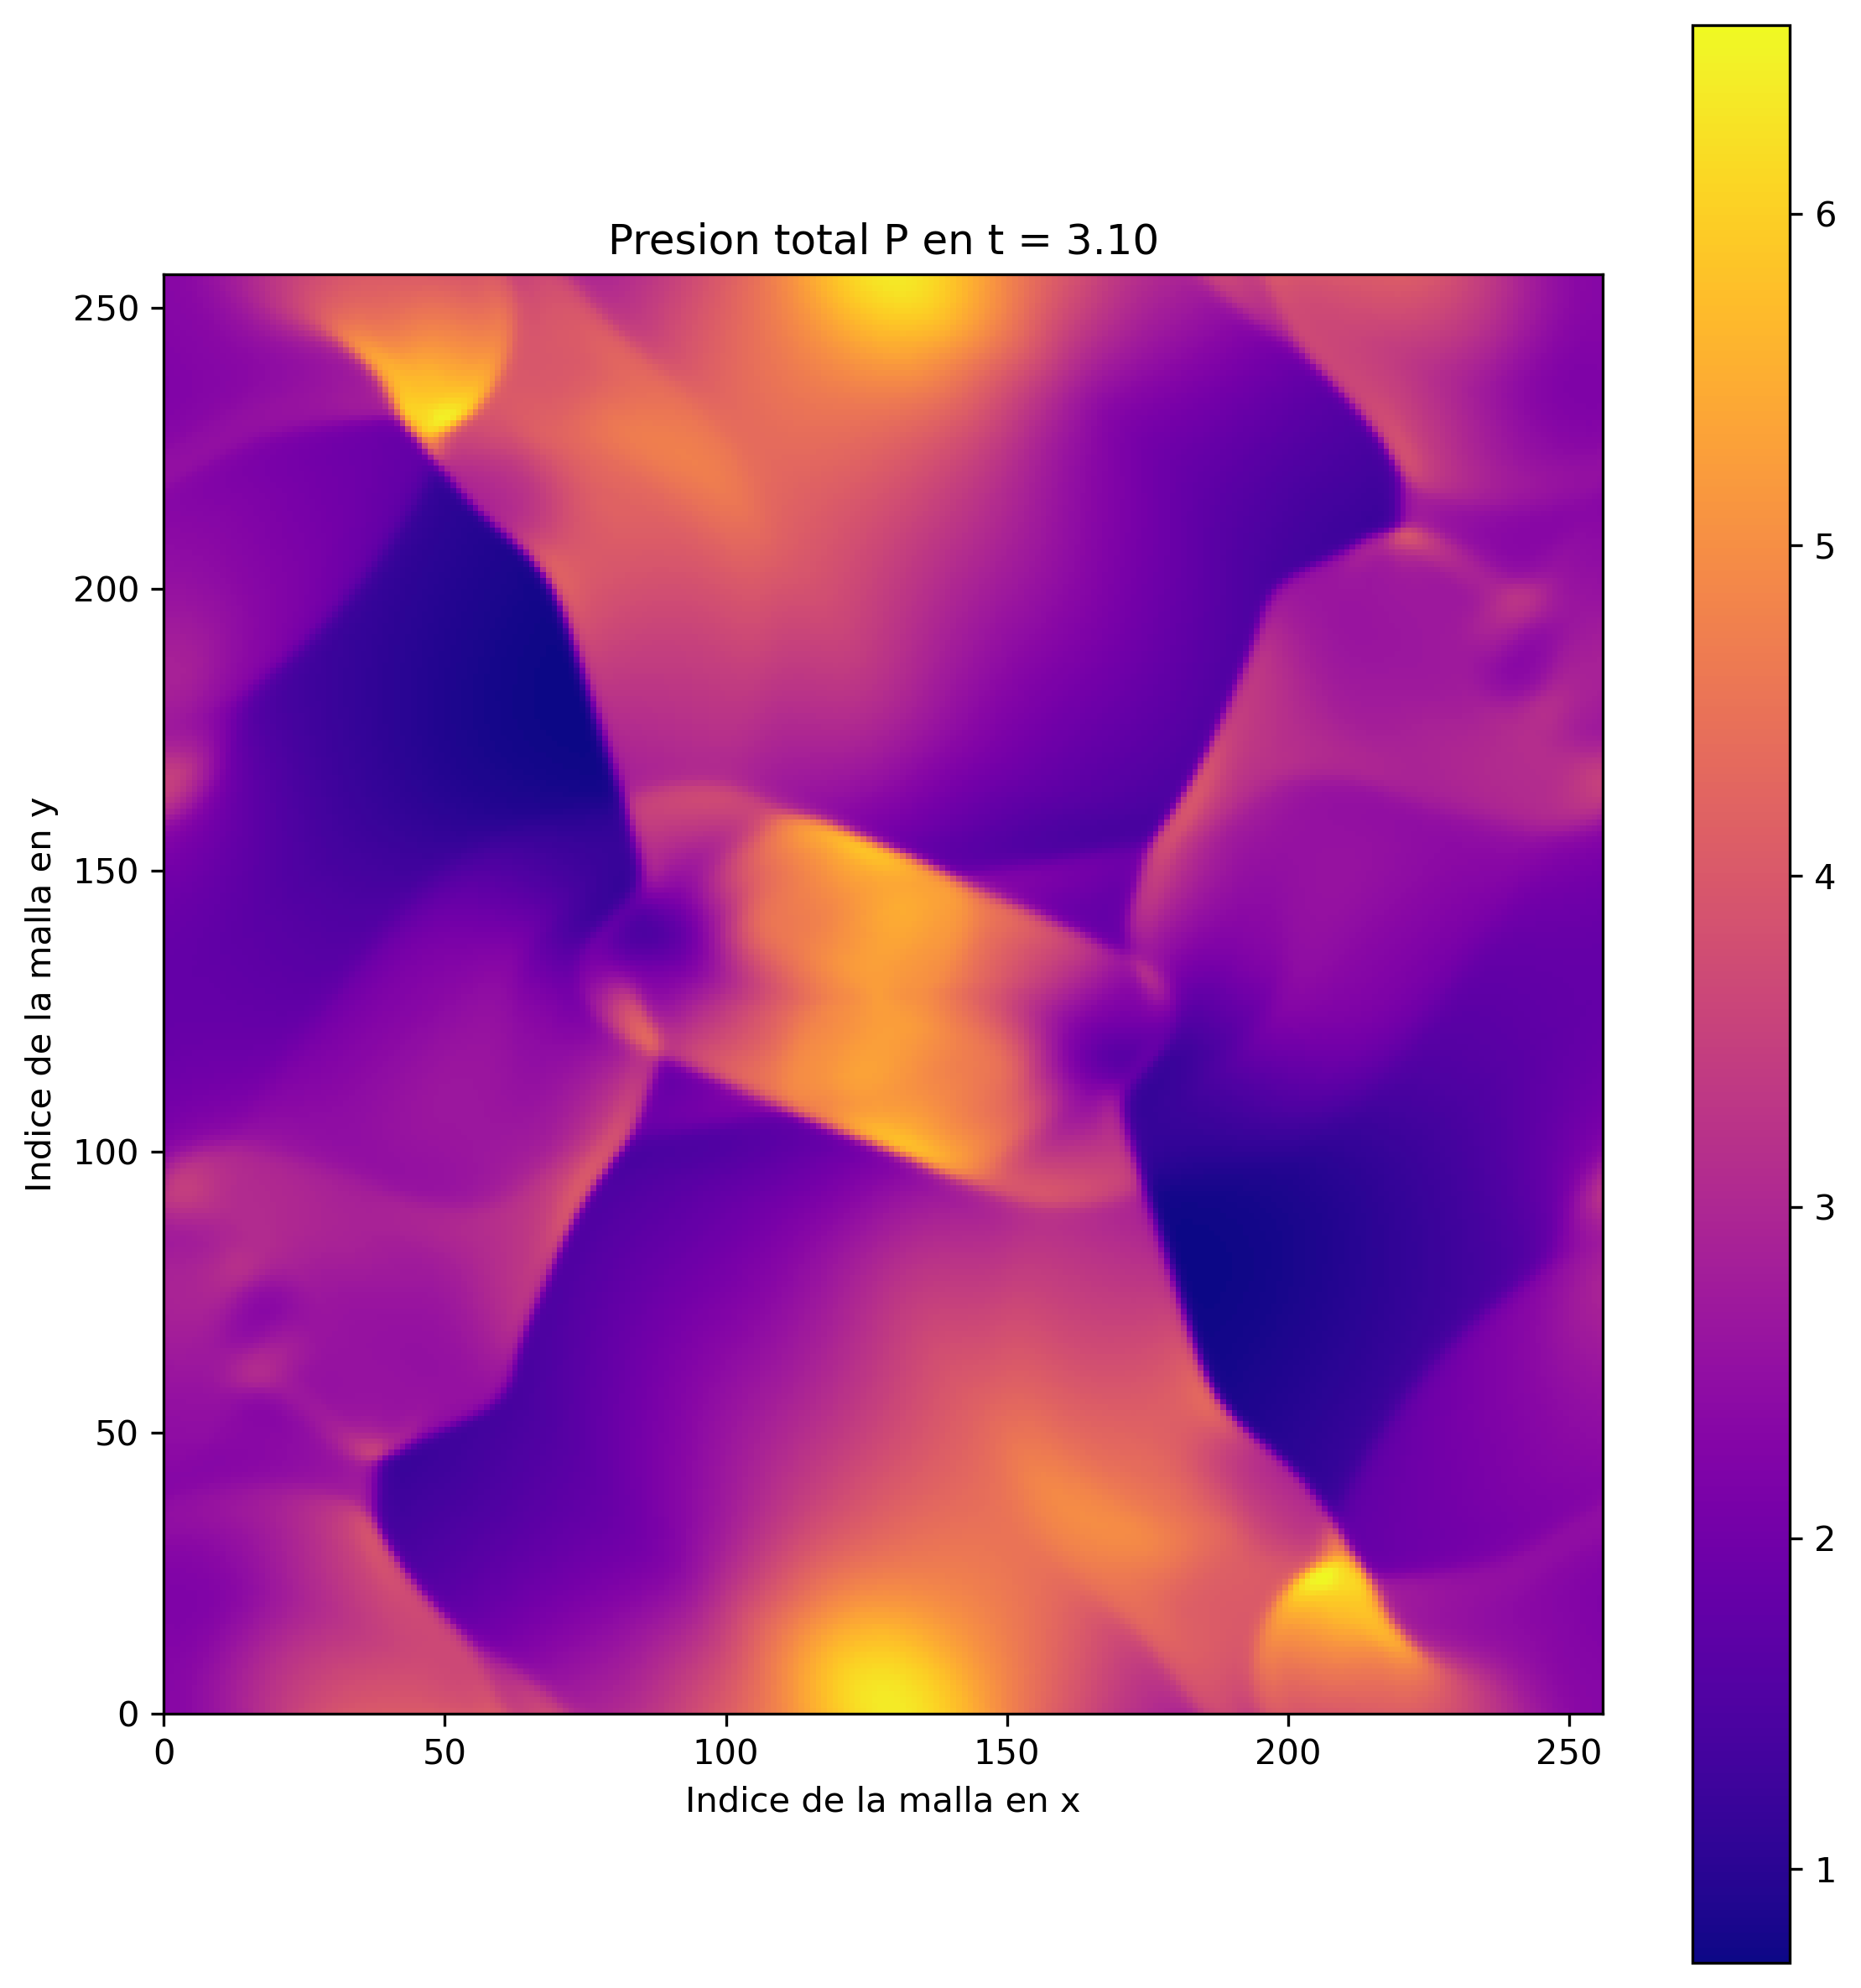

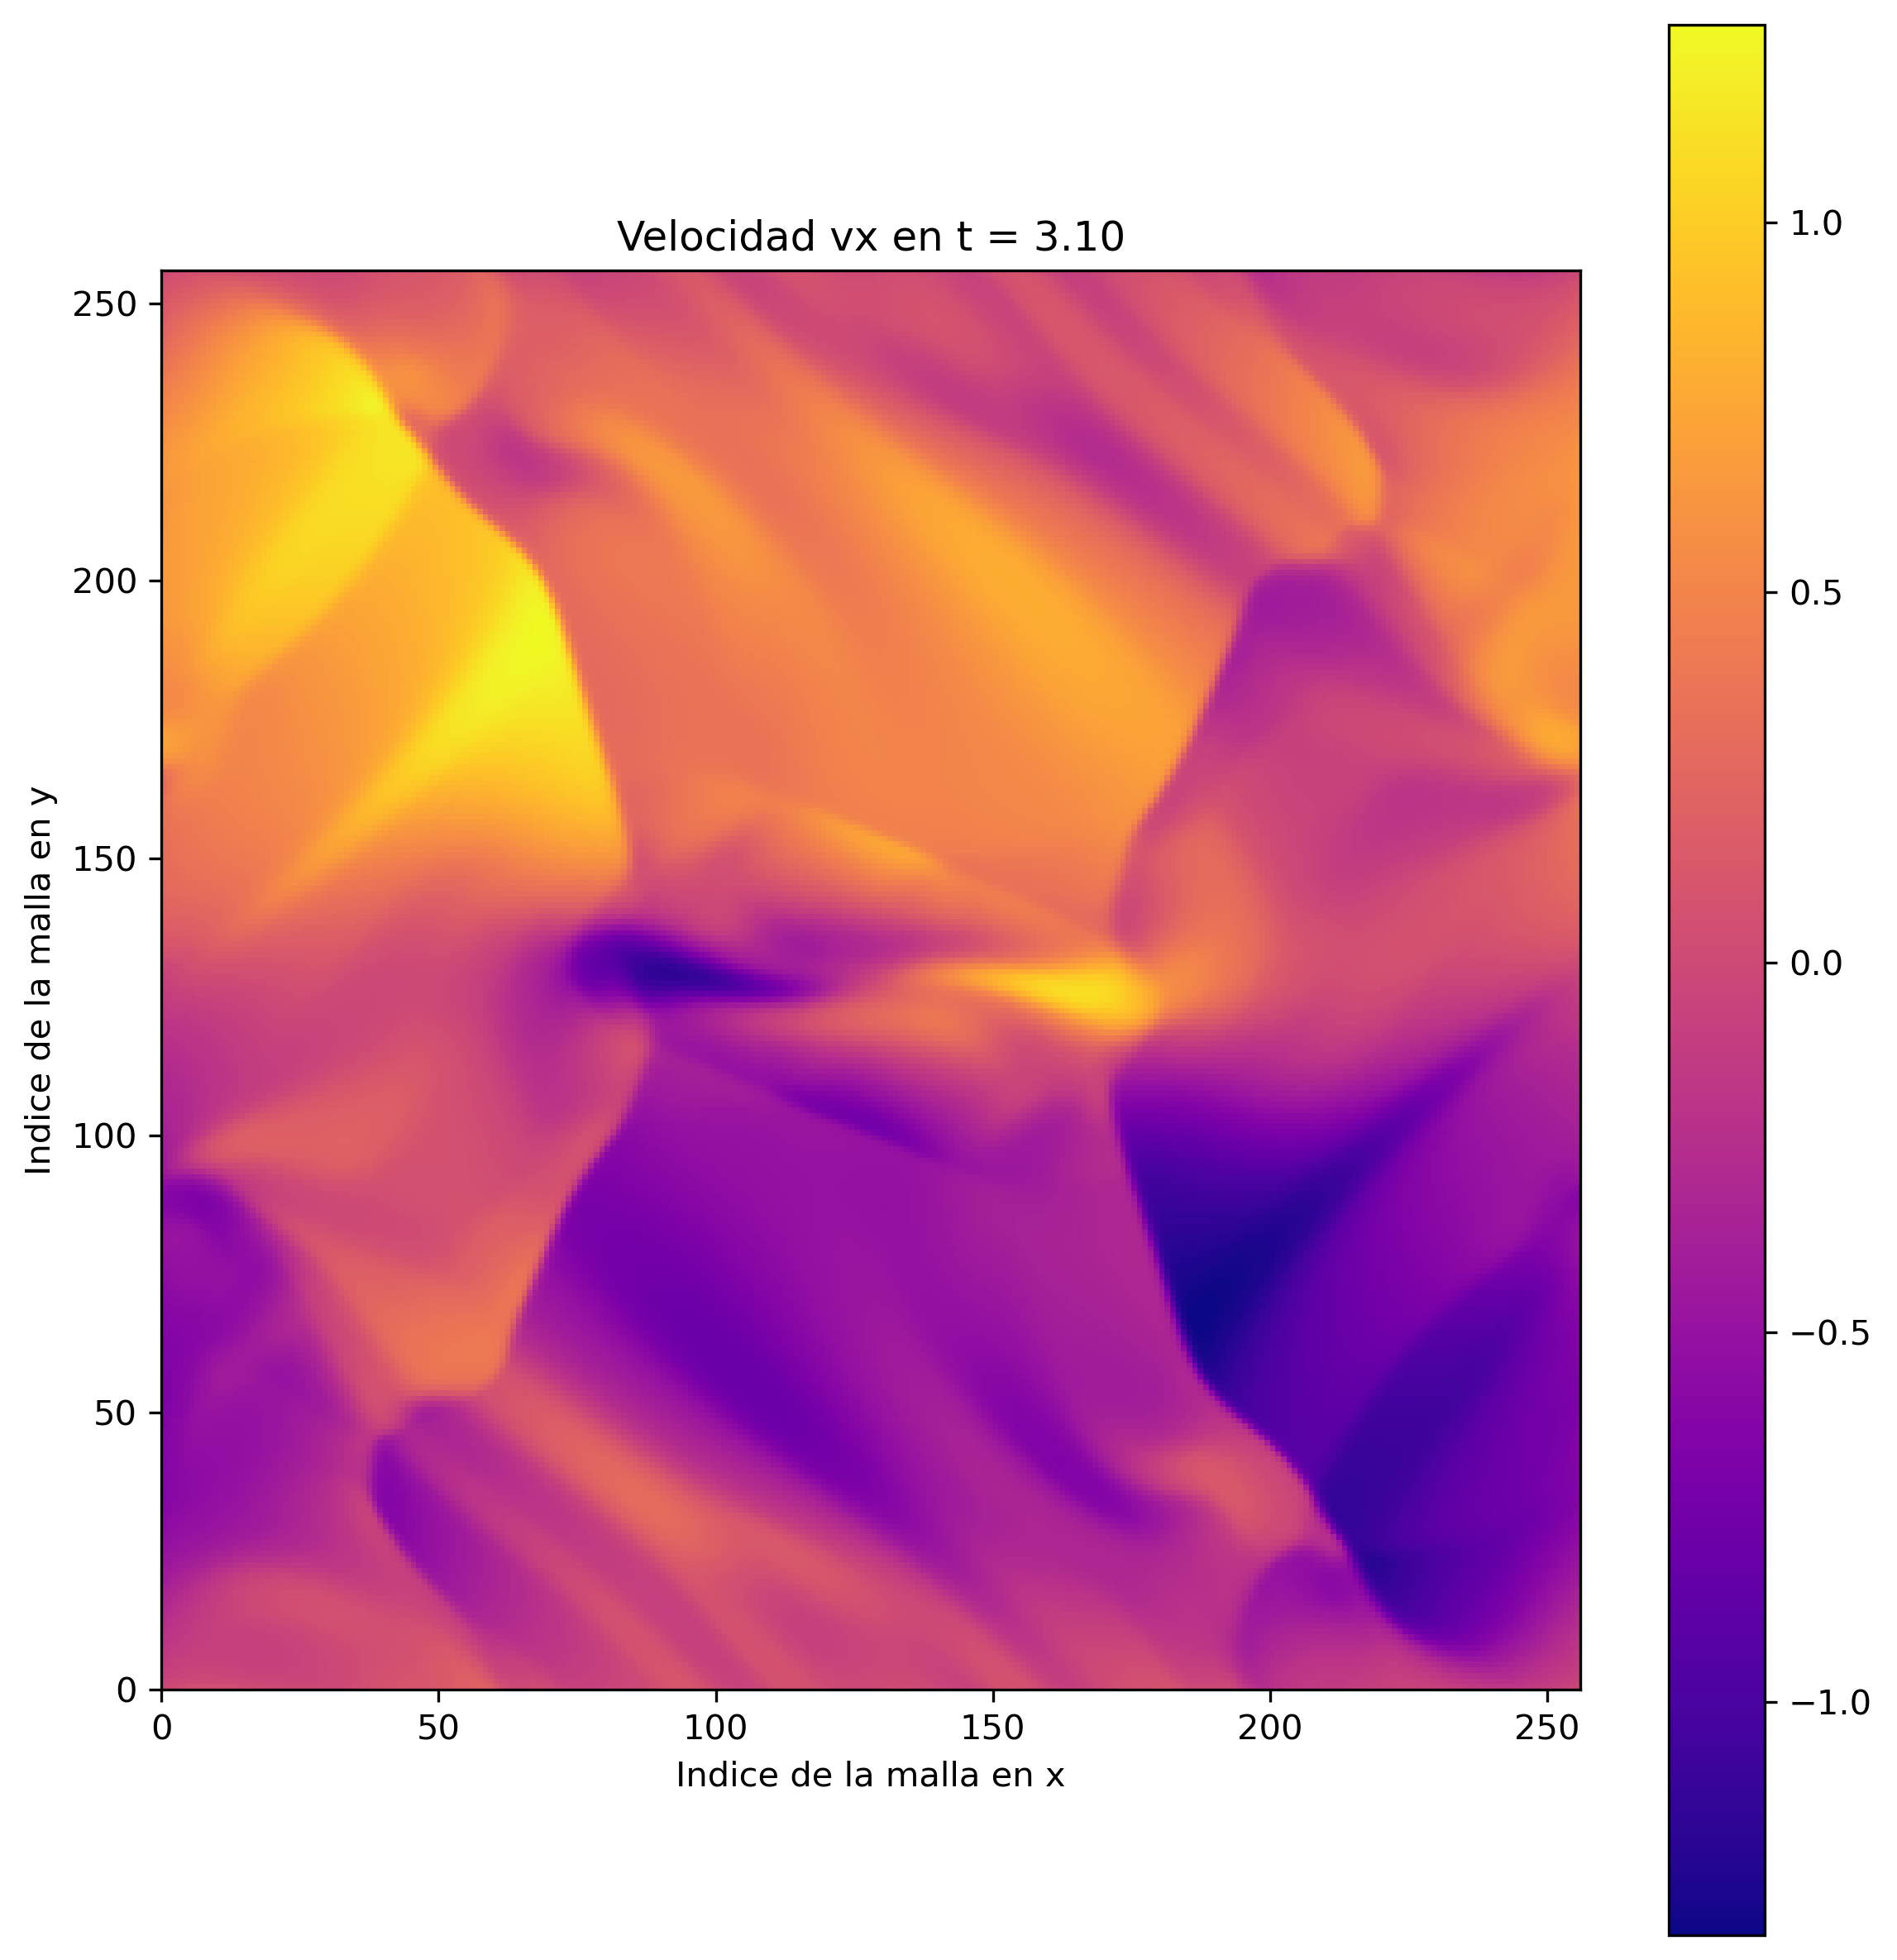

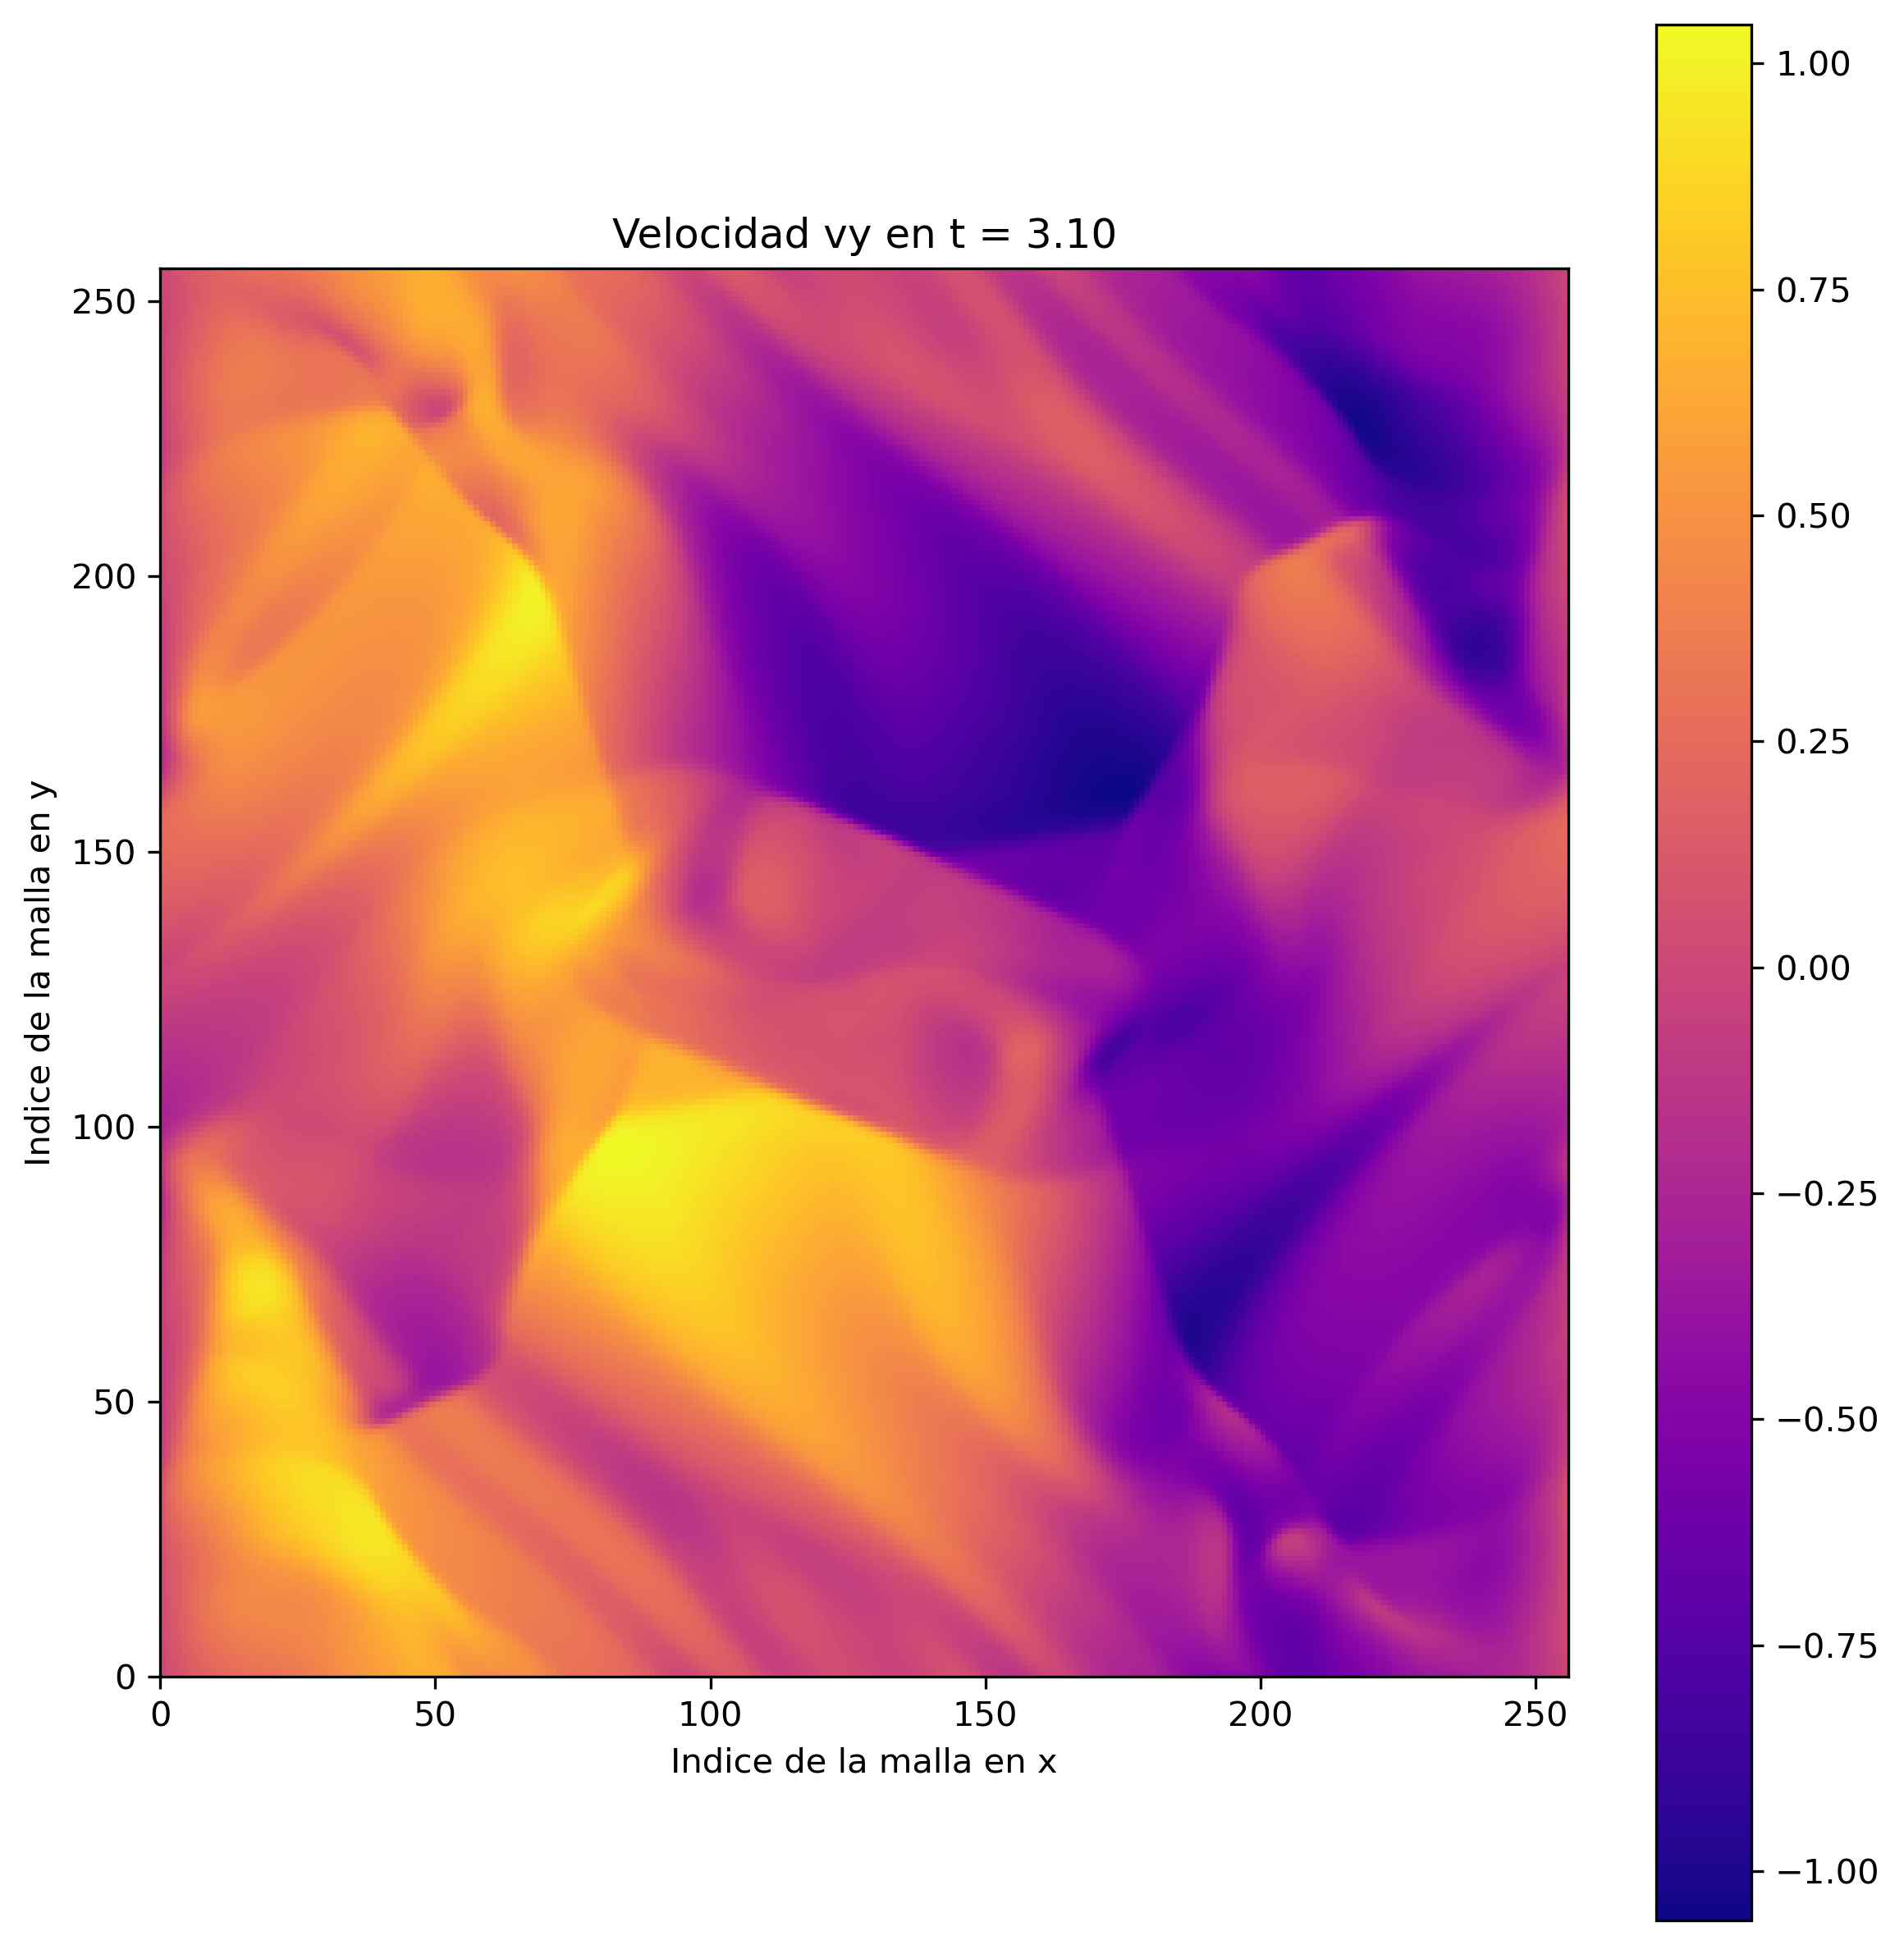

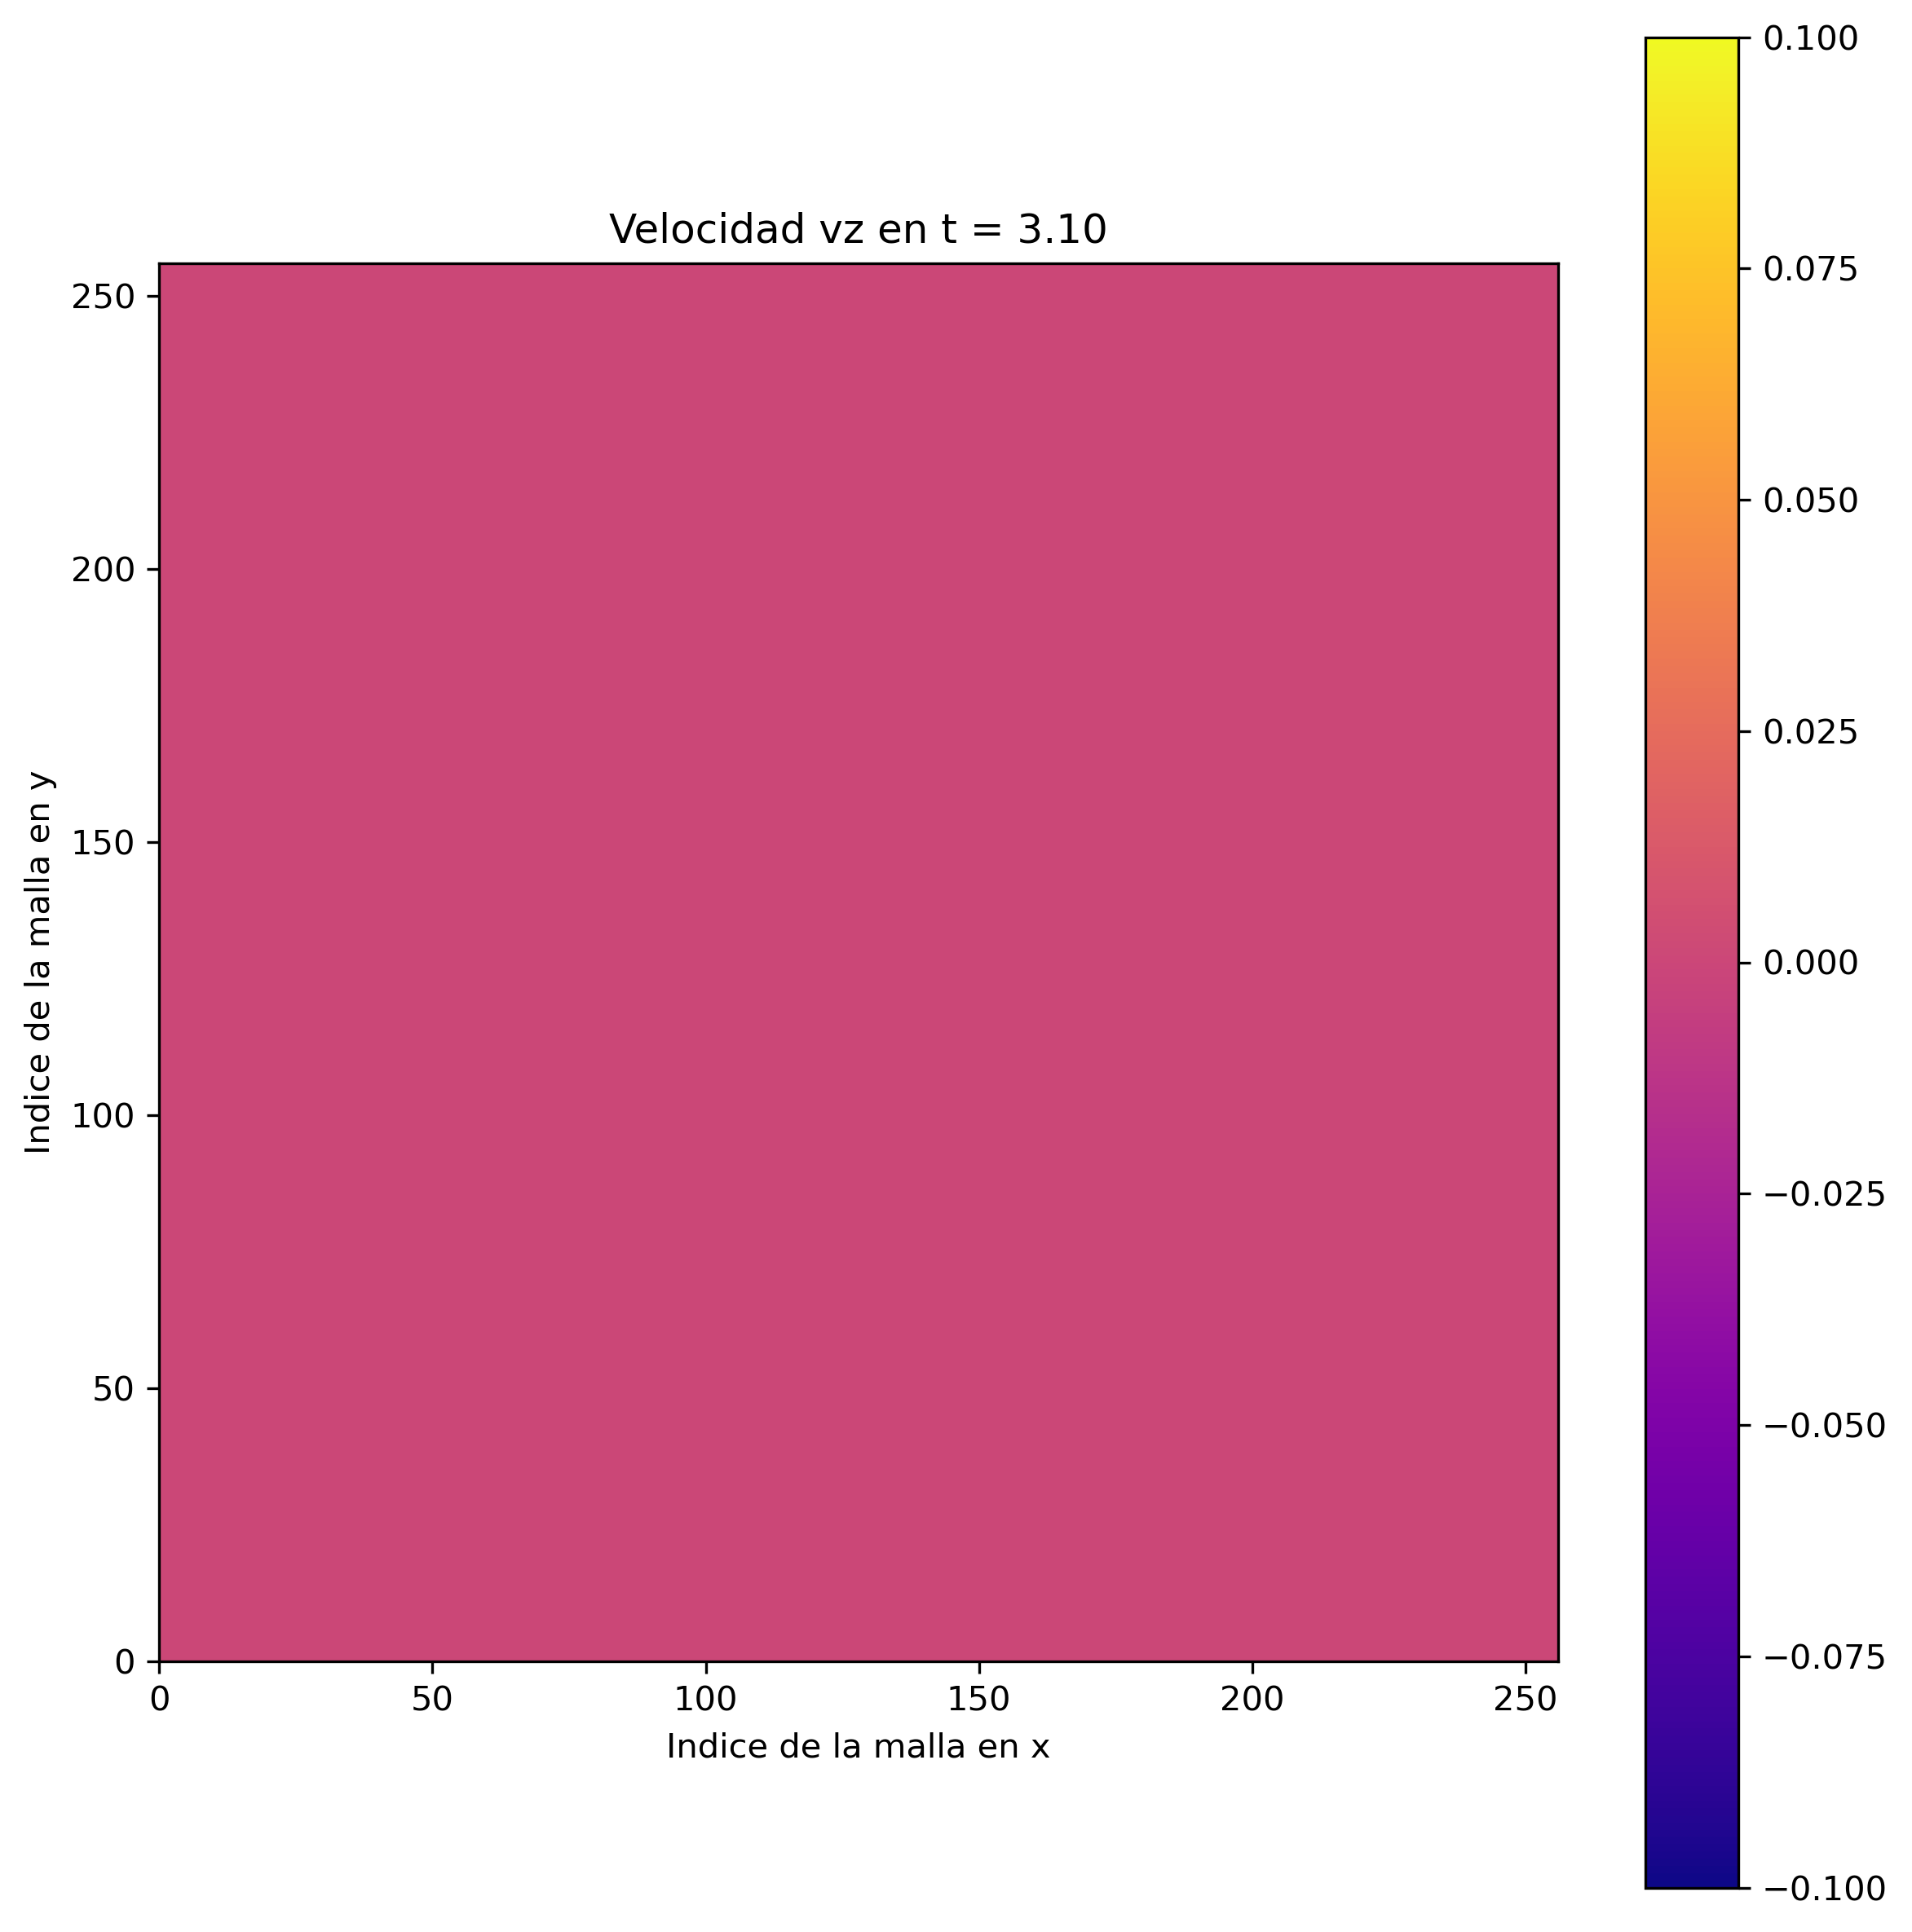

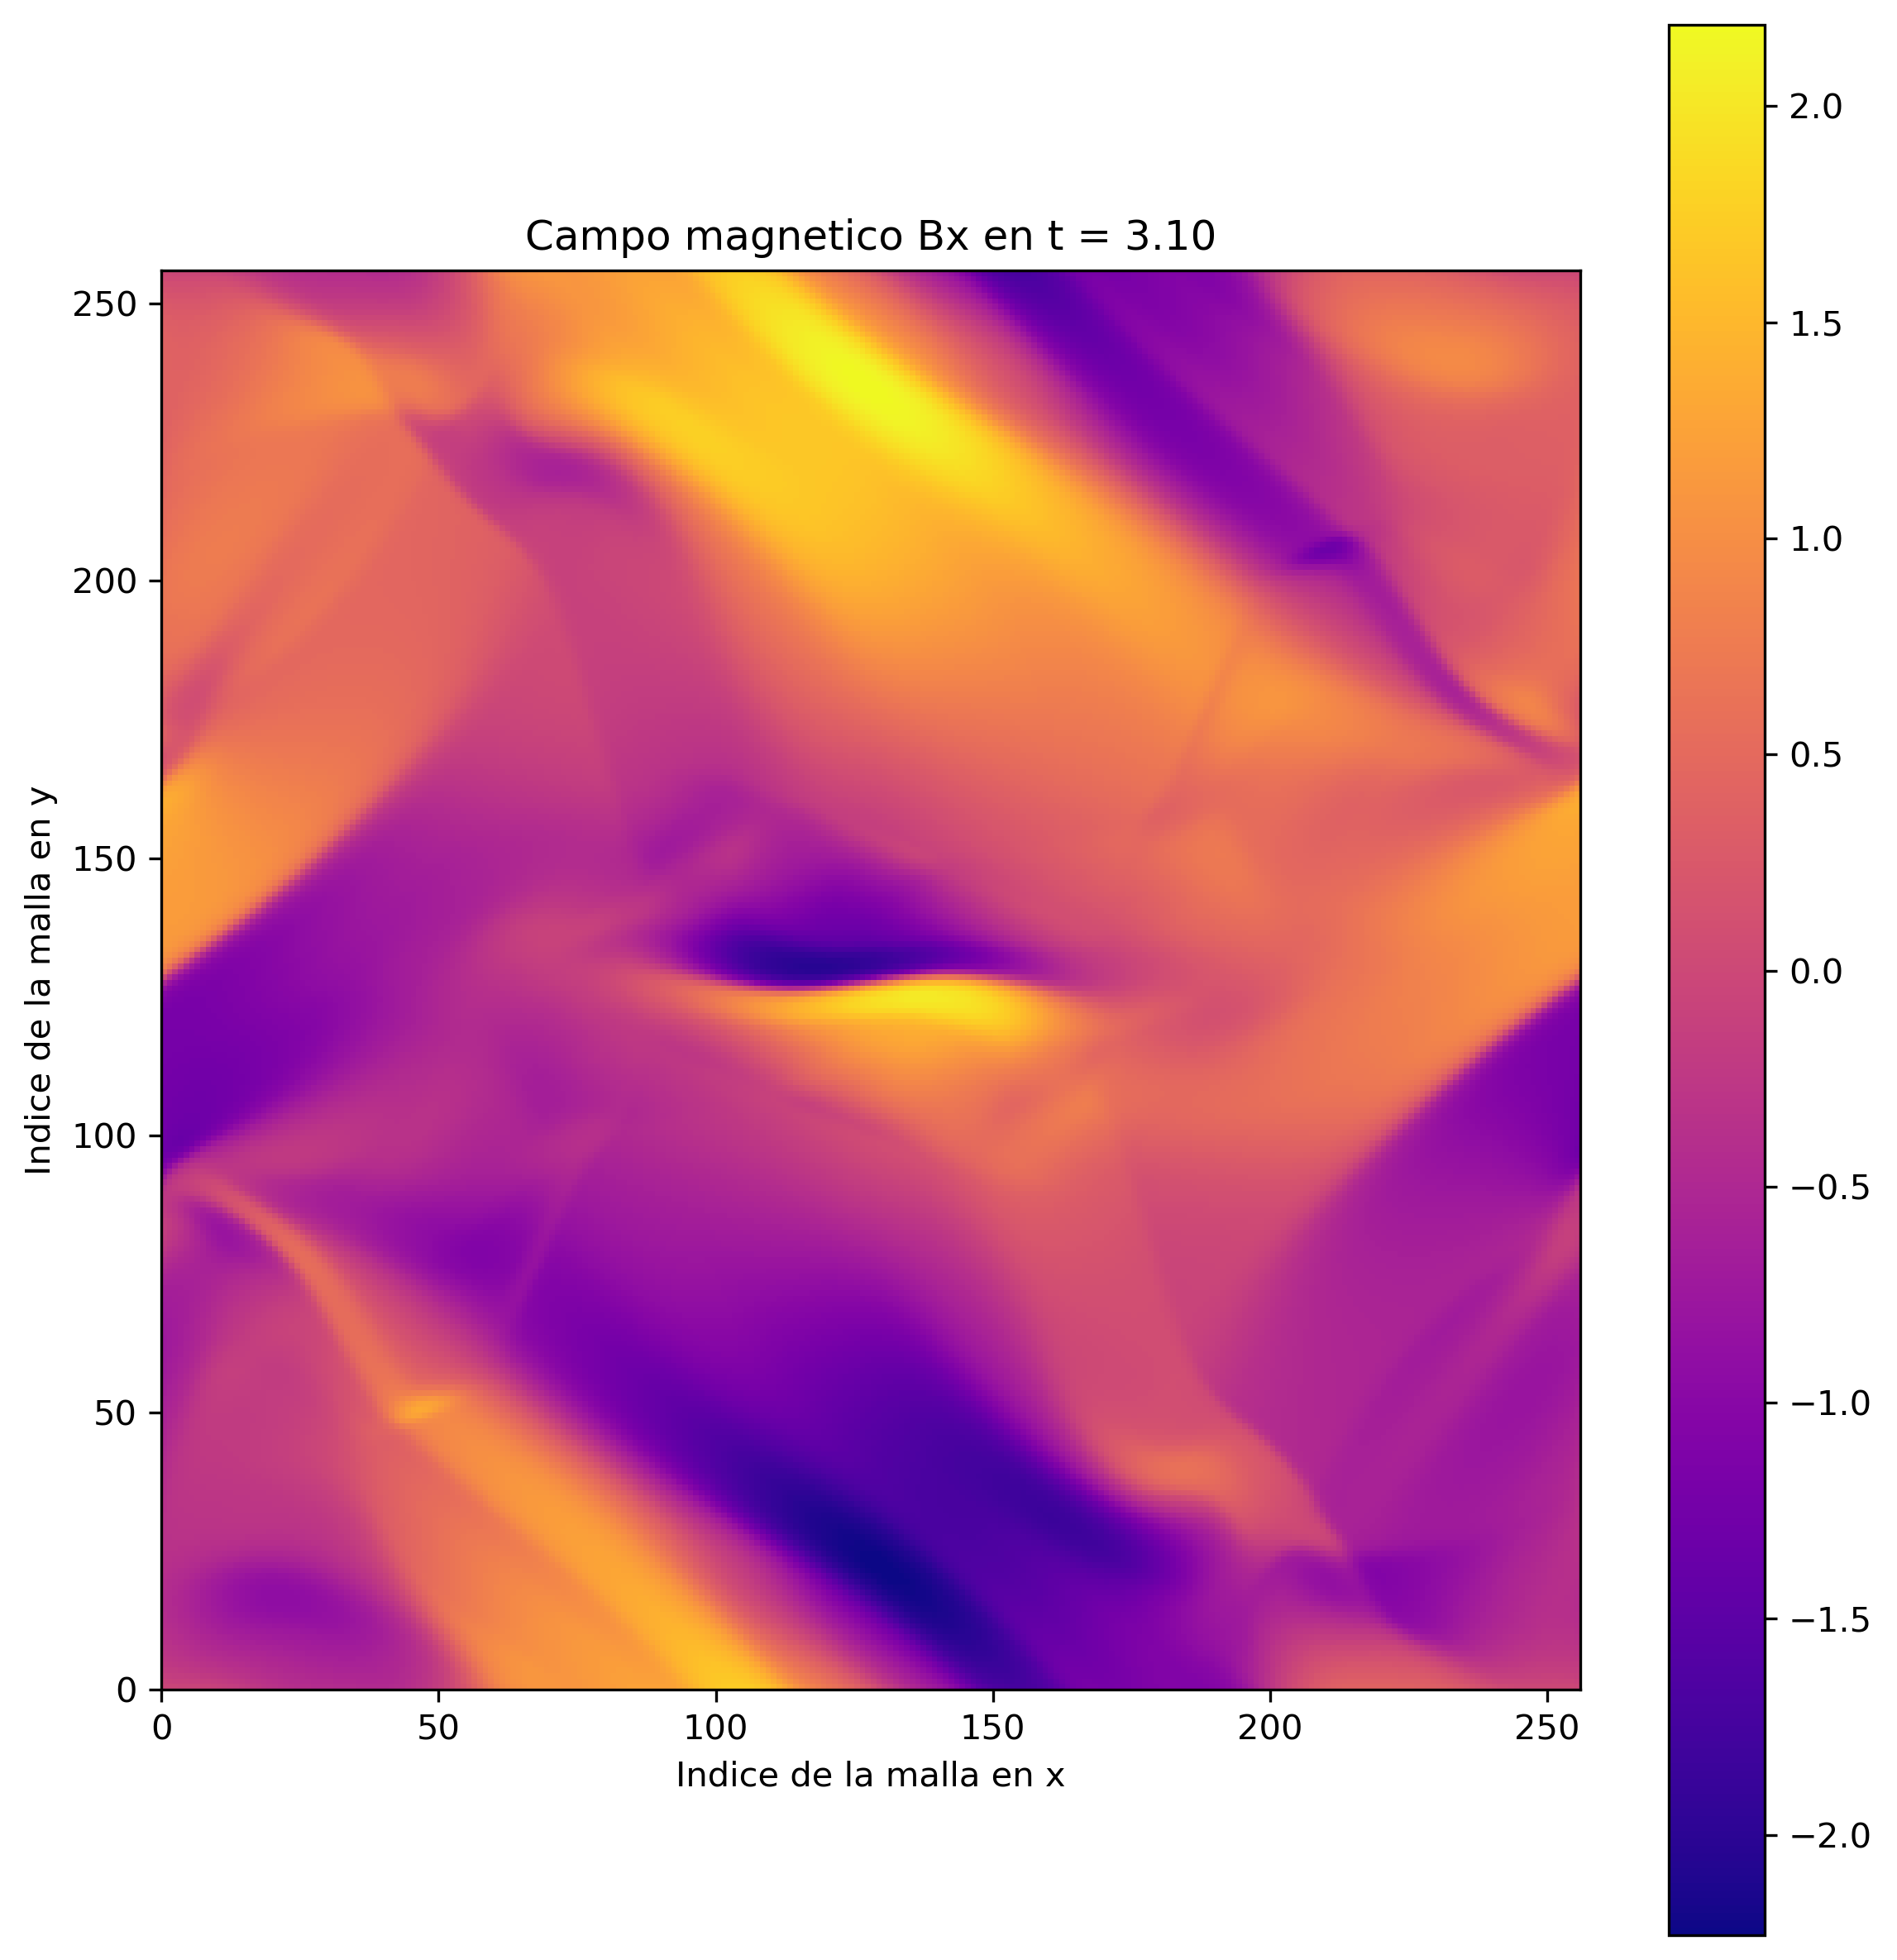

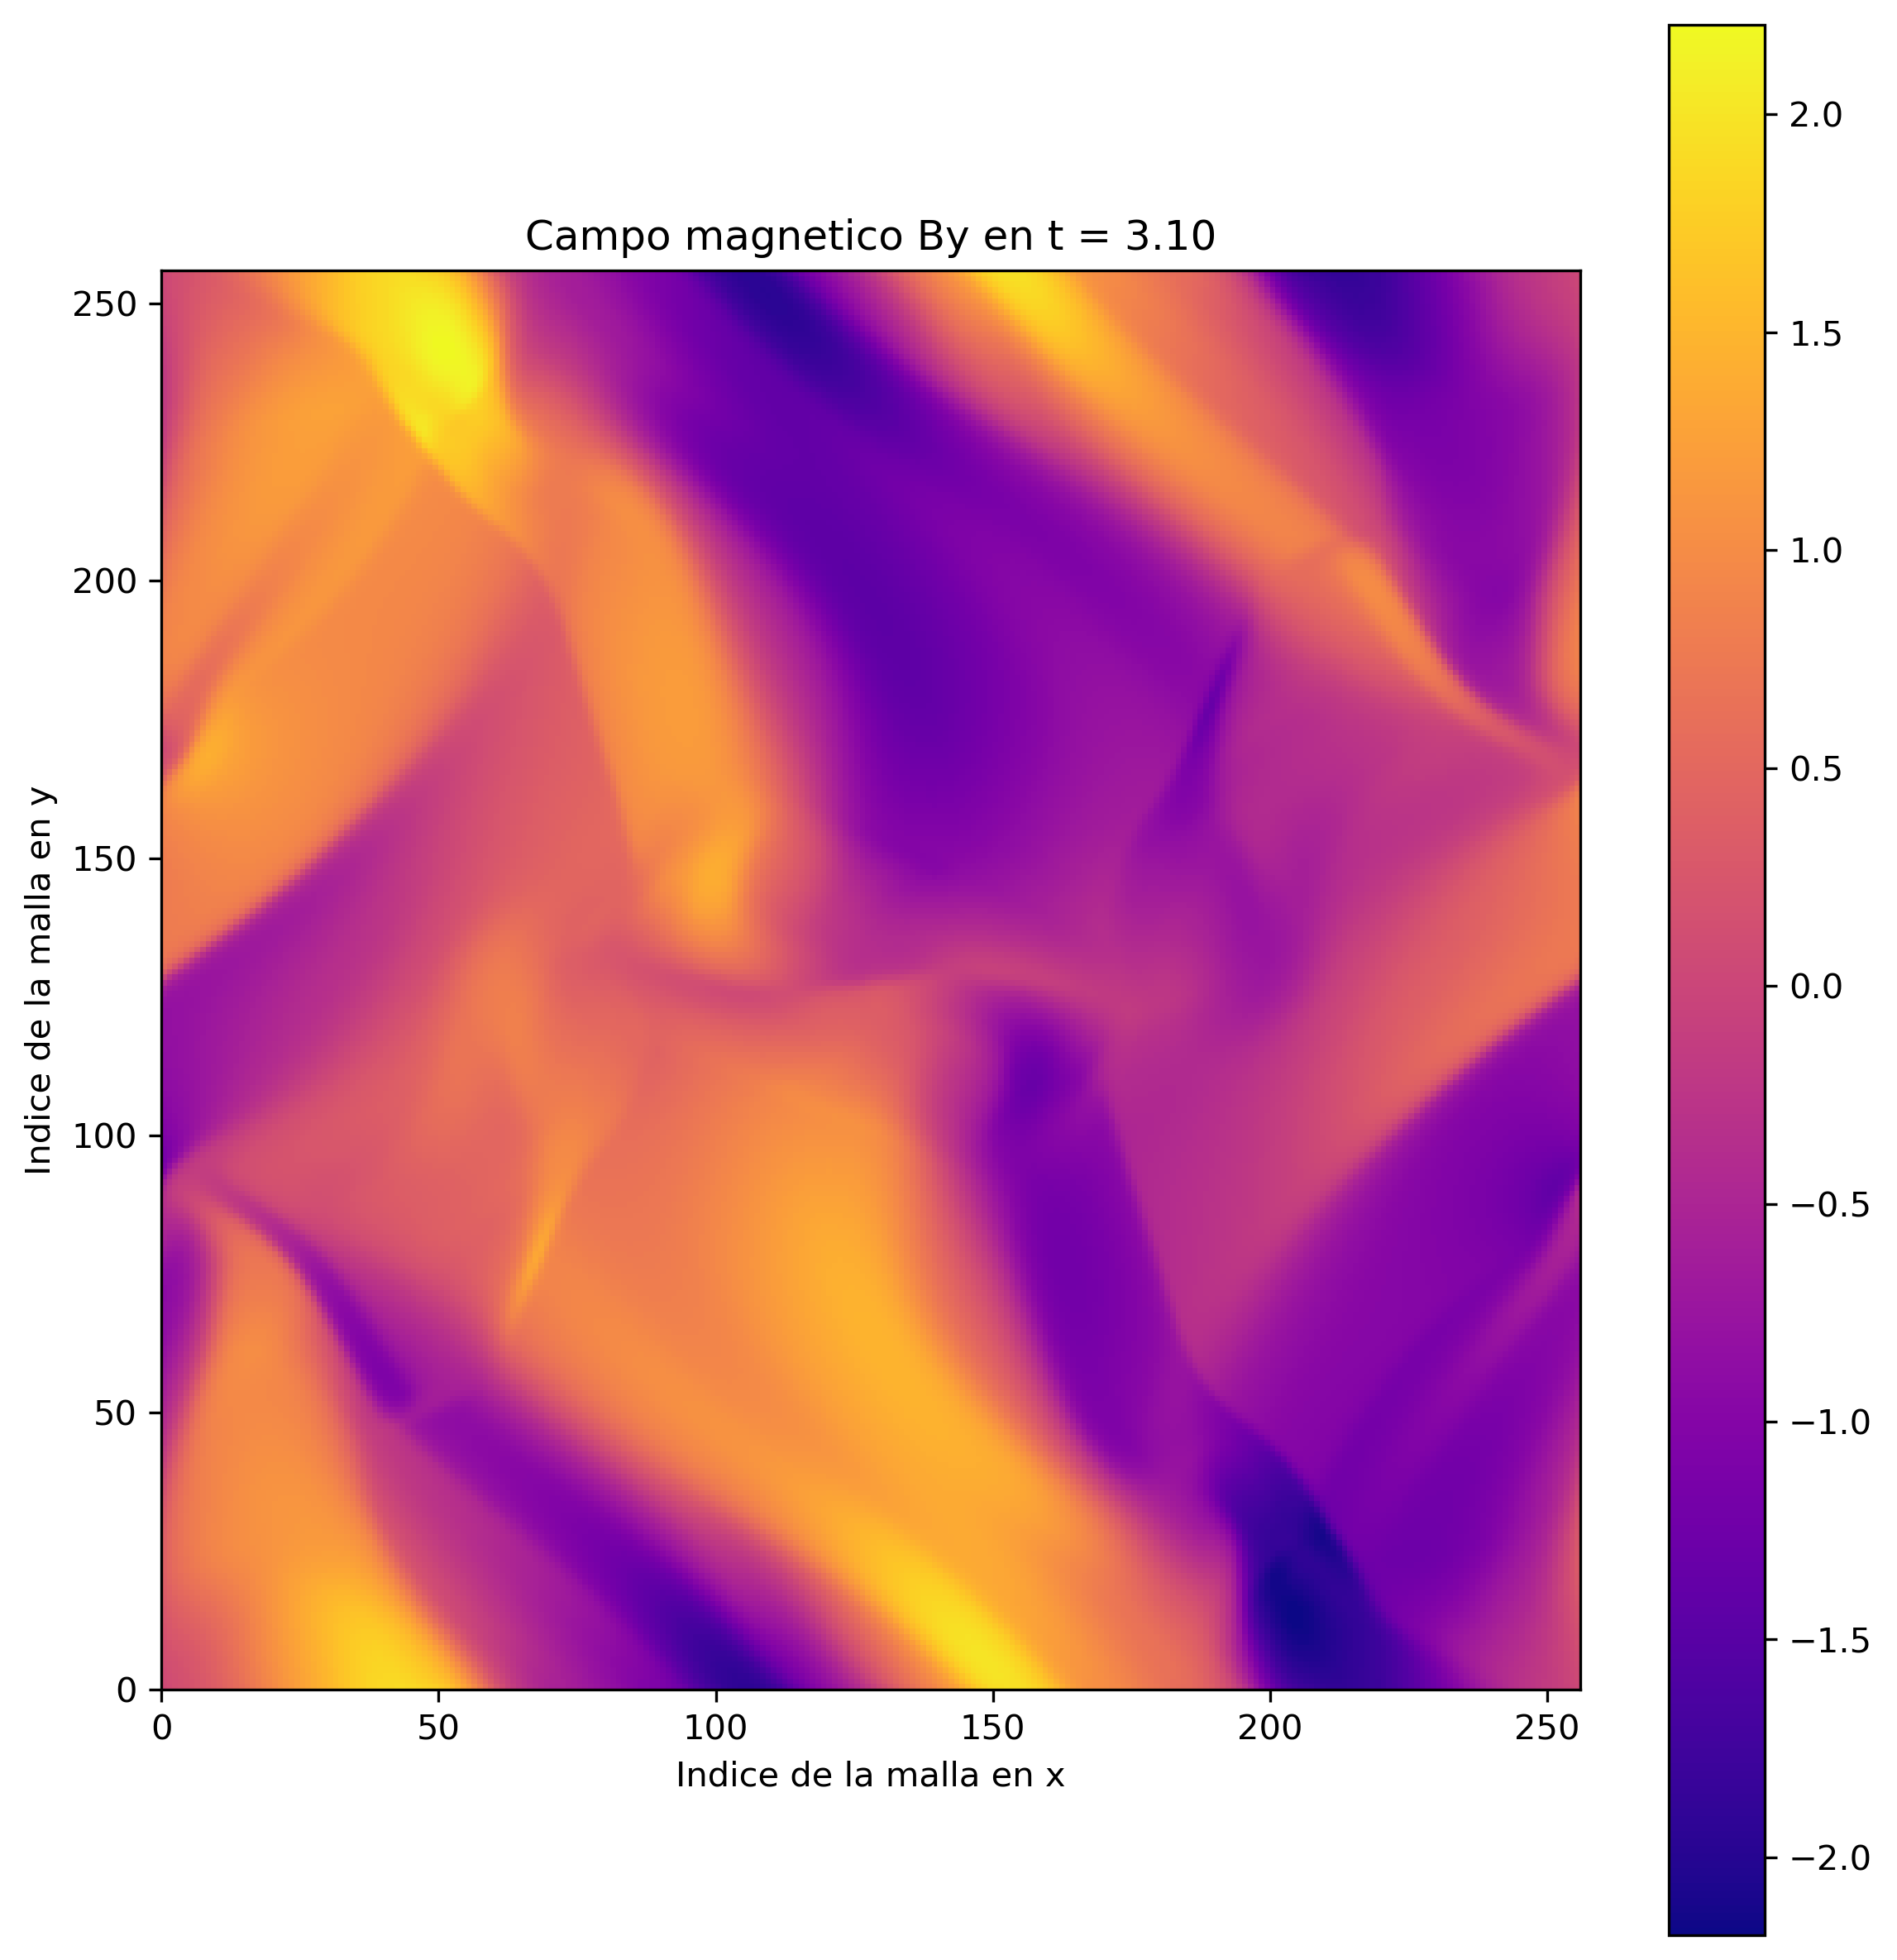

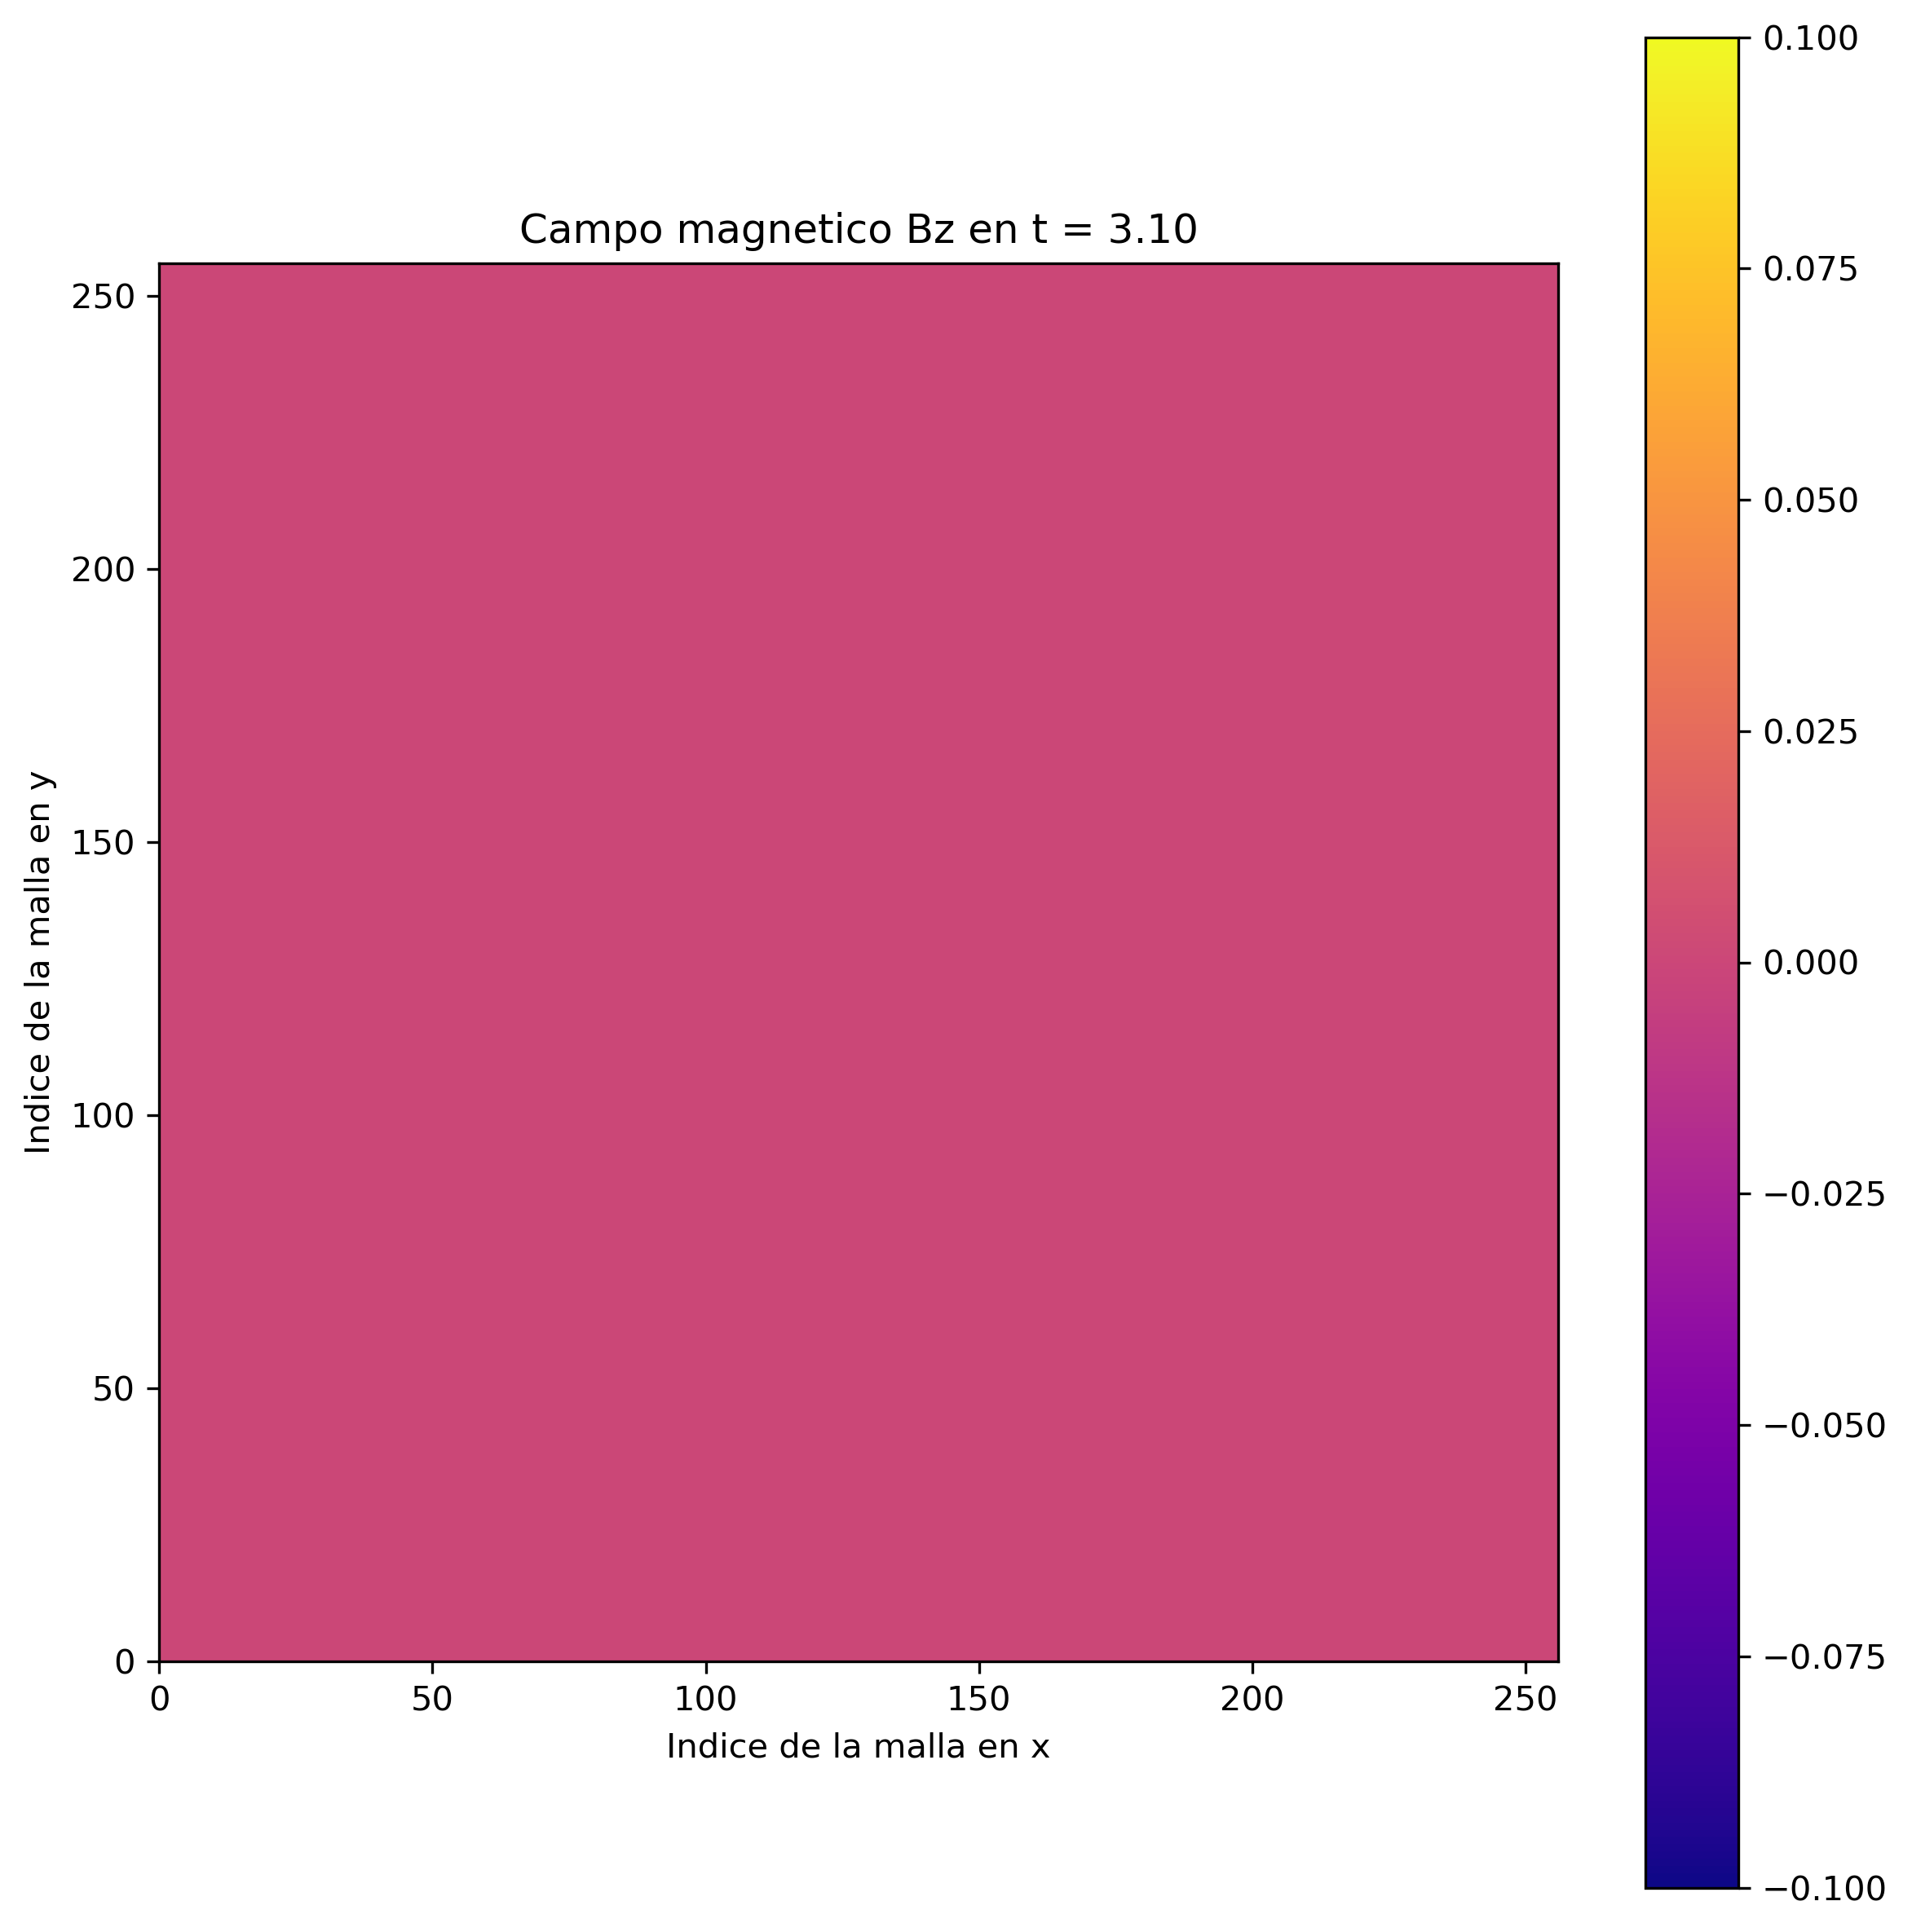

La simulacion termino correctamente.
Tiempo final alcanzado: t = 3.10
Mostre las 8 figuras finales en pantalla.


In [12]:
import matplotlib.pyplot as plt
import numpy as np

"""
 Para este trabajo se utilizó como base el código desarrollado por
 Philip Mocz para simulaciones magnetohidrodinámicas mediante
 constrained transport.
 Sobre esta implementación se realizaron modificaciones en las
 condiciones iniciales y parámetros físicos para reproducir el
 problema de Orszag–Tang estudiado durante la práctica. Los resultados
 obtenidos fueron posteriormente comparados con la solución generada
 mediante PLUTO para analizar las diferencias entre ambas simulaciones
"""


def mostrar_campo(campo, titulo, boxsize):
    """Aqui muestro en pantalla una variable final como mapa 2D."""
    fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
    im = ax.imshow(
        campo.T,
        cmap="plasma",
        origin="lower",
        extent=[0, 256, 0, 256],
        aspect="equal",
    )
    ax.set_title(titulo)
    ax.set_xlabel("Indice de la malla en x")
    ax.set_ylabel("Indice de la malla en y")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


#construyo bx y by a partir del potencial vectorial Az.
def getCurl(Az, dx):
    """
    Esta funcion me permite obtener las componentes del campo magnetico
    en las caras de la malla a partir del potencial vectorial Az.
    """
    L = 1

    bx = (Az - np.roll(Az, L, axis=1)) / dx
    by = -(Az - np.roll(Az, L, axis=0)) / dx

    return bx, by


#reviso si la divergencia magnetica sigue cerca de cero.
def getDiv(bx, by, dx):
    """
    Esta funcion me sirve para calcular la divergencia discreta del campo
    magnetico y verificar que se mantenga aproximadamente nula.
    """
    L = 1

    divB = (bx - np.roll(bx, L, axis=0) + by - np.roll(by, L, axis=1)) / dx

    return divB


# paso el campo magnetico de caras a centros de celda.
def getBavg(bx, by):
    """
    Como el esquema evoluciona el campo en las caras, aqui hago el promedio
    para obtener Bx y By en el centro de cada celda.
    """
    L = 1

    Bx = 0.5 * (bx + np.roll(bx, L, axis=0))
    By = 0.5 * (by + np.roll(by, L, axis=1))

    return Bx, By


#convierto las variables primitivas en variables conservadas.
def getConserved(rho, vx, vy, P, Bx, By, gamma, vol):
    """
    En esta parte construyo masa, momento en x, momento en y y energia,
    que son las cantidades que realmente actualiza el metodo numerico.
    """
    Mass = rho * vol
    Momx = rho * vx * vol
    Momy = rho * vy * vol
    Energy = (
        (P - 0.5 * (Bx**2 + By**2)) / (gamma - 1)
        + 0.5 * rho * (vx**2 + vy**2)
        + 0.5 * (Bx**2 + By**2)
    ) * vol

    return Mass, Momx, Momy, Energy


#recupero las variables fisicas a partir de las conservadas.
def getPrimitive(Mass, Momx, Momy, Energy, Bx, By, gamma, vol):
    """
    Despues de cada actualizacion, aqui vuelvo a calcular densidad,
    velocidades y presion total para seguir avanzando la simulacion.
    """
    rho = Mass / vol
    vx = Momx / rho / vol
    vy = Momy / rho / vol
    P = (Energy / vol - 0.5 * rho * (vx**2 + vy**2) - 0.5 * (Bx**2 + By**2)) * (
        gamma - 1
    ) + 0.5 * (Bx**2 + By**2)

    return rho, vx, vy, P


#calculo gradientes espaciales centrados.
def getGradient(f, dx):
    """
    Esta funcion me da los gradientes espaciales de cualquier variable
    para luego poder reconstruir los estados en las caras.
    """
    R = -1
    L = 1

    f_dx = (np.roll(f, R, axis=0) - np.roll(f, L, axis=0)) / (2 * dx)
    f_dy = (np.roll(f, R, axis=1) - np.roll(f, L, axis=1)) / (2 * dx)

    return f_dx, f_dy


#limito los gradientes para evitar oscilaciones no fisicas.
def slopeLimit(f, dx, f_dx, f_dy):
    """
    En esta parte aplico un limitador para que la reconstruccion no genere
    oscilaciones artificiales cerca de choques o transiciones fuertes.
    """
    R = -1
    L = 1

    f_dx = (
        np.maximum(
            0.0,
            np.minimum(
                1.0, ((f - np.roll(f, L, axis=0)) / dx) / (f_dx + 1.0e-8 * (f_dx == 0))
            ),
        )
        * f_dx
    )
    f_dx = (
        np.maximum(
            0.0,
            np.minimum(
                1.0, (-(f - np.roll(f, R, axis=0)) / dx) / (f_dx + 1.0e-8 * (f_dx == 0))
            ),
        )
        * f_dx
    )
    f_dy = (
        np.maximum(
            0.0,
            np.minimum(
                1.0, ((f - np.roll(f, L, axis=1)) / dx) / (f_dy + 1.0e-8 * (f_dy == 0))
            ),
        )
        * f_dy
    )
    f_dy = (
        np.maximum(
            0.0,
            np.minimum(
                1.0, (-(f - np.roll(f, R, axis=1)) / dx) / (f_dy + 1.0e-8 * (f_dy == 0))
            ),
        )
        * f_dy
    )

    return f_dx, f_dy


#reconstruyo los estados a izquierda y derecha de cada cara.
def extrapolateInSpaceToFace(f, f_dx, f_dy, dx):
    """
    Esta reconstruccion me permite aproximar los valores de cada variable
    en las caras de las celdas antes de calcular los flujos.
    """
    R = -1

    f_XL = f - f_dx * dx / 2
    f_XL = np.roll(f_XL, R, axis=0)
    f_XR = f + f_dx * dx / 2

    f_YL = f - f_dy * dx / 2
    f_YL = np.roll(f_YL, R, axis=1)
    f_YR = f + f_dy * dx / 2

    return f_XL, f_XR, f_YL, f_YR


#actualizo una variable conservada usando los flujos numericos.
def applyFluxes(F, flux_F_X, flux_F_Y, dx, dt):
    """
    En esta parte aplico el balance de flujos para actualizar cada variable
    conservada en el tiempo.
    """
    L = 1

    F += -dt * dx * flux_F_X
    F += dt * dx * np.roll(flux_F_X, L, axis=0)
    F += -dt * dx * flux_F_Y
    F += dt * dx * np.roll(flux_F_Y, L, axis=1)

    return F


#actualizo el campo magnetico con constrained transport.
def constrainedTransport(bx, by, flux_By_X, flux_Bx_Y, dx, dt):
    """
    Esta funcion es importante porque me ayuda a mantener controlada
    la divergencia del campo magnetico durante toda la evolucion.
    """
    R = -1

    Ez = 0.25 * (
        -flux_By_X
        - np.roll(flux_By_X, R, axis=1)
        + flux_Bx_Y
        + np.roll(flux_Bx_Y, R, axis=0)
    )
    dbx, dby = getCurl(-Ez, dx)

    bx += dt * dbx
    by += dt * dby

    return bx, by


#calculo los flujos numericos entre celdas vecinas.
def getFlux(
    rho_L, rho_R, vx_L, vx_R, vy_L, vy_R, P_L, P_R, Bx_L, Bx_R, By_L, By_R, gamma
):
    """
    En esta funcion uso una aproximacion tipo Rusanov para calcular
    los flujos de masa, momento, energia y campo magnetico.
    """

    en_L = (
        (P_L - 0.5 * (Bx_L**2 + By_L**2)) / (gamma - 1)
        + 0.5 * rho_L * (vx_L**2 + vy_L**2)
        + 0.5 * (Bx_L**2 + By_L**2)
    )
    en_R = (
        (P_R - 0.5 * (Bx_R**2 + By_R**2)) / (gamma - 1)
        + 0.5 * rho_R * (vx_R**2 + vy_R**2)
        + 0.5 * (Bx_R**2 + By_R**2)
    )

    rho_star = 0.5 * (rho_L + rho_R)
    momx_star = 0.5 * (rho_L * vx_L + rho_R * vx_R)
    momy_star = 0.5 * (rho_L * vy_L + rho_R * vy_R)
    en_star = 0.5 * (en_L + en_R)
    Bx_star = 0.5 * (Bx_L + Bx_R)
    By_star = 0.5 * (By_L + By_R)

    P_star = (gamma - 1) * (
        en_star
        - 0.5 * (momx_star**2 + momy_star**2) / rho_star
        - 0.5 * (Bx_star**2 + By_star**2)
    ) + 0.5 * (Bx_star**2 + By_star**2)

    flux_Mass = momx_star
    flux_Momx = momx_star**2 / rho_star + P_star - Bx_star * Bx_star
    flux_Momy = momx_star * momy_star / rho_star - Bx_star * By_star
    flux_Energy = (en_star + P_star) * momx_star / rho_star - Bx_star * (
        Bx_star * momx_star + By_star * momy_star
    ) / rho_star
    flux_By = (By_star * momx_star - Bx_star * momy_star) / rho_star

    c0_L = np.sqrt(gamma * (P_L - 0.5 * (Bx_L**2 + By_L**2)) / rho_L)
    c0_R = np.sqrt(gamma * (P_R - 0.5 * (Bx_R**2 + By_R**2)) / rho_R)
    ca_L = np.sqrt((Bx_L**2 + By_L**2) / rho_L)
    ca_R = np.sqrt((Bx_R**2 + By_R**2) / rho_R)
    cf_L = np.sqrt(0.5 * (c0_L**2 + ca_L**2) + 0.5 * np.sqrt((c0_L**2 + ca_L**2) ** 2))
    cf_R = np.sqrt(0.5 * (c0_R**2 + ca_R**2) + 0.5 * np.sqrt((c0_R**2 + ca_R**2) ** 2))
    C_L = cf_L + np.abs(vx_L)
    C_R = cf_R + np.abs(vx_R)
    C = np.maximum(C_L, C_R)

    flux_Mass -= C * 0.5 * (rho_L - rho_R)
    flux_Momx -= C * 0.5 * (rho_L * vx_L - rho_R * vx_R)
    flux_Momy -= C * 0.5 * (rho_L * vy_L - rho_R * vy_R)
    flux_Energy -= C * 0.5 * (en_L - en_R)
    flux_By -= C * 0.5 * (By_L - By_R)

    return flux_Mass, flux_Momx, flux_Momy, flux_Energy, flux_By


#ejecuto toda la simulacion, desde la malla hasta las figuras finales.
def main():
    """Aqui corro toda la simulacion del problema de Orszag-Tang."""

    #parametros principales del problema.
    N = 256
    boxsize = 2 * np.pi
    gamma = 5 / 3
    courant_fac = 0.4
    t = 0
    tEnd = 3.10
    tOut = 0.10
    useSlopeLimiting = True

    #construyo la malla del dominio.
    dx = boxsize / N
    vol = dx**2
    xlin = (np.arange(N) + 0.5) * dx
    Y, X = np.meshgrid(xlin, xlin)
    xlin_node = np.arange(N) * dx
    Yn, Xn = np.meshgrid(xlin_node, xlin_node)

    #impongo las mismas condiciones iniciales que use en PLUTO.
    rho = (25 / 9) * np.ones(X.shape)
    vx = -np.sin(Y)
    vy = np.sin(X)
    pgas0 = (5 / 3) * np.ones(X.shape)

    #defino el potencial vectorial para construir el campo magnetico.
    Az = np.cos(Yn) + 0.5 * np.cos(2 * Xn)
    bx, by = getCurl(Az, dx)
    Bx, By = getBavg(bx, by)

    #sumo la presion magnetica para obtener la presion total.
    P = pgas0 + 0.5 * (Bx**2 + By**2)

    #paso todo a variables conservadas para empezar la evolucion.
    Mass, Momx, Momy, Energy = getConserved(rho, vx, vy, P, Bx, By, gamma, vol)

    outputCount = 1

    #hago avanzar la simulacion en el tiempo.
    while t < tEnd:
        while outputCount * tOut <= t + 1.0e-12:
            outputCount += 1

        #recupero las variables fisicas actuales.
        Bx, By = getBavg(bx, by)
        rho, vx, vy, P = getPrimitive(Mass, Momx, Momy, Energy, Bx, By, gamma, vol)

        #calculo el paso temporal usando la condicion CFL.
        c0 = np.sqrt(gamma * (P - 0.5 * (Bx**2 + By**2)) / rho)
        ca = np.sqrt((Bx**2 + By**2) / rho)
        cf = np.sqrt(0.5 * (c0**2 + ca**2) + 0.5 * np.sqrt((c0**2 + ca**2) ** 2))
        dt = courant_fac * np.min(dx / (cf + np.sqrt(vx**2 + vy**2)))
        if (not np.isfinite(dt)) or dt <= 0.0:
            raise RuntimeError(f"Paso temporal invalido: dt={dt} en t={t}")
        if t + dt > tEnd:
            dt = tEnd - t
        if t + dt >= outputCount * tOut - 1.0e-12:
            dt = outputCount * tOut - t

        #calculo los gradientes espaciales.
        rho_dx, rho_dy = getGradient(rho, dx)
        vx_dx, vx_dy = getGradient(vx, dx)
        vy_dx, vy_dy = getGradient(vy, dx)
        P_dx, P_dy = getGradient(P, dx)
        Bx_dx, Bx_dy = getGradient(Bx, dx)
        By_dx, By_dy = getGradient(By, dx)

        #aplico el limitador para estabilizar la reconstruccion.
        if useSlopeLimiting:
            rho_dx, rho_dy = slopeLimit(rho, dx, rho_dx, rho_dy)
            vx_dx, vx_dy = slopeLimit(vx, dx, vx_dx, vx_dy)
            vy_dx, vy_dy = slopeLimit(vy, dx, vy_dx, vy_dy)
            P_dx, P_dy = slopeLimit(P, dx, P_dx, P_dy)
            Bx_dx, Bx_dy = slopeLimit(Bx, dx, Bx_dx, Bx_dy)
            By_dx, By_dy = slopeLimit(By, dx, By_dx, By_dy)

        #hago la extrapolacion de medio paso en el tiempo.
        rho_prime = rho - 0.5 * dt * (
            vx * rho_dx + rho * vx_dx + vy * rho_dy + rho * vy_dy
        )
        vx_prime = vx - 0.5 * dt * (
            vx * vx_dx
            + vy * vx_dy
            + (1 / rho) * P_dx
            - (2 * Bx / rho) * Bx_dx
            - (By / rho) * Bx_dy
            - (Bx / rho) * By_dy
        )
        vy_prime = vy - 0.5 * dt * (
            vx * vy_dx
            + vy * vy_dy
            + (1 / rho) * P_dy
            - (2 * By / rho) * By_dy
            - (Bx / rho) * By_dx
            - (By / rho) * Bx_dx
        )
        P_prime = P - 0.5 * dt * (
            (gamma * (P - 0.5 * (Bx**2 + By**2)) + By**2) * vx_dx
            - Bx * By * vy_dx
            + vx * P_dx
            + (gamma - 2) * (Bx * vx + By * vy) * Bx_dx
            - By * Bx * vx_dy
            + (gamma * (P - 0.5 * (Bx**2 + By**2)) + Bx**2) * vy_dy
            + vy * P_dy
            + (gamma - 2) * (Bx * vx + By * vy) * By_dy
        )
        Bx_prime = Bx - 0.5 * dt * (-By * vx_dy + Bx * vy_dy + vy * Bx_dy - vx * By_dy)
        By_prime = By - 0.5 * dt * (By * vx_dx - Bx * vy_dx - vy * Bx_dx + vx * By_dx)

        #reconstruyo los estados en las caras.
        rho_XL, rho_XR, rho_YL, rho_YR = extrapolateInSpaceToFace(
            rho_prime, rho_dx, rho_dy, dx
        )
        vx_XL, vx_XR, vx_YL, vx_YR = extrapolateInSpaceToFace(
            vx_prime, vx_dx, vx_dy, dx
        )
        vy_XL, vy_XR, vy_YL, vy_YR = extrapolateInSpaceToFace(
            vy_prime, vy_dx, vy_dy, dx
        )
        P_XL, P_XR, P_YL, P_YR = extrapolateInSpaceToFace(P_prime, P_dx, P_dy, dx)
        Bx_XL, Bx_XR, Bx_YL, Bx_YR = extrapolateInSpaceToFace(
            Bx_prime, Bx_dx, Bx_dy, dx
        )
        By_XL, By_XR, By_YL, By_YR = extrapolateInSpaceToFace(
            By_prime, By_dx, By_dy, dx
        )

        #calculo los flujos en x y en y.
        flux_Mass_X, flux_Momx_X, flux_Momy_X, flux_Energy_X, flux_By_X = getFlux(
            rho_XL,
            rho_XR,
            vx_XL,
            vx_XR,
            vy_XL,
            vy_XR,
            P_XL,
            P_XR,
            Bx_XL,
            Bx_XR,
            By_XL,
            By_XR,
            gamma,
        )
        flux_Mass_Y, flux_Momy_Y, flux_Momx_Y, flux_Energy_Y, flux_Bx_Y = getFlux(
            rho_YL,
            rho_YR,
            vy_YL,
            vy_YR,
            vx_YL,
            vx_YR,
            P_YL,
            P_YR,
            By_YL,
            By_YR,
            Bx_YL,
            Bx_YR,
            gamma,
        )

        #actualizo masa, momento, energia y campo magnetico.
        Mass = applyFluxes(Mass, flux_Mass_X, flux_Mass_Y, dx, dt)
        Momx = applyFluxes(Momx, flux_Momx_X, flux_Momx_Y, dx, dt)
        Momy = applyFluxes(Momy, flux_Momy_X, flux_Momy_Y, dx, dt)
        Energy = applyFluxes(Energy, flux_Energy_X, flux_Energy_Y, dx, dt)
        bx, by = constrainedTransport(bx, by, flux_By_X, flux_Bx_Y, dx, dt)

        #avanzo el tiempo.
        t += dt

    #recupero las variables finales para poder graficarlas.
    Bx, By = getBavg(bx, by)
    rho, vx, vy, P = getPrimitive(Mass, Momx, Momy, Energy, Bx, By, gamma, vol)
    vz = np.zeros_like(rho)
    Bz = np.zeros_like(rho)

    #muestro las figuras finales en pantalla.
    mostrar_campo(rho, "Densidad rho en t = 3.10", boxsize)
    mostrar_campo(P, "Presion total P en t = 3.10", boxsize)
    mostrar_campo(vx, "Velocidad vx en t = 3.10", boxsize)
    mostrar_campo(vy, "Velocidad vy en t = 3.10", boxsize)
    mostrar_campo(vz, "Velocidad vz en t = 3.10", boxsize)
    mostrar_campo(Bx, "Campo magnetico Bx en t = 3.10", boxsize)
    mostrar_campo(By, "Campo magnetico By en t = 3.10", boxsize)
    mostrar_campo(Bz, "Campo magnetico Bz en t = 3.10", boxsize)

    print("La simulacion termino correctamente.")
    print(f"Tiempo final alcanzado: t = {t:.2f}")
    print("Mostre las 8 figuras finales en pantalla.")

    return 0


if __name__ == "__main__":
    main()

In [8]:
import numpy as np

data = np.load("python_solution_t310.npz")

print(data.files)

['rho', 'prs', 'vx1', 'vx2', 'vx3', 'Bx1', 'Bx2', 'Bx3']


In [9]:
for key in data.files:
    print(key, data[key].shape)

rho (256, 256)
prs (256, 256)
vx1 (256, 256)
vx2 (256, 256)
vx3 (256, 256)
Bx1 (256, 256)
Bx2 (256, 256)
Bx3 (256, 256)


<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Conclusiones y observaciones finales
</h3>

<p>
En este notebook se implementó una versión en Python del problema magnetohidrodinámico de Orszag–Tang y se generaron las distribuciones finales de densidad, presión, velocidad y campo magnético para un tiempo de simulación (<code>t = 3.10</code>).
</p>

<p>
Las figuras obtenidas muestran la formación de estructuras complejas asociadas a la evolución no lineal del plasma, incluyendo regiones de compresión, gradientes pronunciados y patrones característicos de turbulencia magnetohidrodinámica. Las variables de densidad, presión, velocidad en el plano (<code>v<sub>x</sub></code> y <code>v<sub>y</sub></code>) y campo magnético en el plano (<code>B<sub>x</sub></code> y <code>B<sub>y</sub></code>) presentan distribuciones espaciales no uniformes que reflejan la interacción entre el movimiento del fluido y el campo magnético.
</p>

<p>
Por otro lado, las componentes <code>v<sub>z</sub></code> y <code>B<sub>z</sub></code> permanecen prácticamente nulas durante toda la simulación. Esto ocurre porque el problema clásico de Orszag–Tang está formulado en dos dimensiones, por lo que la dinámica se desarrolla únicamente en el plano <code>x-y</code>. Como consecuencia, las figuras correspondientes a estas variables aparecen prácticamente uniformes y sin estructuras físicas significativas. Las pequeñas fluctuaciones observadas en <code>B<sub>z</sub></code> son del orden de la precisión numérica de la máquina y no representan fenómenos físicos reales, sino errores de redondeo asociados a los cálculos computacionales.
</p>

<p>
Las figuras generadas en este notebook constituyen la base para la comparación con la solución de referencia obtenida mediante PLUTO. El análisis cuantitativo de errores, la comparación detallada entre ambas implementaciones y la discusión de las discrepancias observadas se presentan en el informe final asociado a este trabajo.
</p>

<p>
En conjunto, los resultados obtenidos permiten reproducir las principales características físicas del problema de Orszag–Tang y constituyen una aproximación válida para el estudio numérico de fenómenos magnetohidrodinámicos mediante herramientas desarrolladas en Python. Aunque existen diferencias cuantitativas respecto a la solución de referencia, particularmente en la variable presión, la implementación desarrollada captura adecuadamente la dinámica global del sistema y reproduce las estructuras fundamentales esperadas para este problema de referencia en magnetohidrodinámica.
</p>

</div>